## **Context**
Customer segmentation is the process of dividing a dataset of customers into groups of similar customers based o certain common characteristics, usually for the purpose of understanding the popultion dataset in a better fashion. Understanding customer behavior and characteristics is usually a critical part of the market operations of any business or organization, with direct consequences on sales and marketing strategy. Customer segmentation is often viewed as a means to achieve a better return on investment from marketing efforts, and make organizations more efficient in terms on utilizing their money, time, and other critical resources in customer marketing strategies for different groups of customers based on their unique needs and motivations.

For example, it has been understood from various research that customer segmentation often has a huge impact on people's email engagement. Segmented campaigns often see over 100% more clicks than non-segmented campaigns, and email marketers who have segmented their audience before campaigning have reported a 6-7 times growth in their overall revenue. It has also been observed in various contexts that in today's world, individual customers perfer personalized communications and offerings that cater to their particular interests.

In the context of marketing analytics then, customer segmentation has a vital role to play in optimizing ROI. It typically involves analyzing metrics around customer engagement with various markenting activities including but not limited to, ATL (above the line) marketing activities, BTL (below the line) campaings, and targeting personalized offers. Typically, the variables of interest are channels. Based on these feature categories, the target is to create the best possible customer segments from the given data.

## **Objective**

The objective is to develop meaningful customer segments that help the business deliver more personalized marketing and improve return on investment. We will use dimensionality reduction techniques to simplify the dataset by capturing the most important behavioral and channel-engagement patterns while reducing noise and redundancy. Using the reduced feature space, we will apply clustering methods to group customers into distinct segments based on similarity in engagement, channel preferences, and response behavior. We will evaluate segment quality using clustering validation measures and business interpretability to ensure the groups are both statistically sound and actionable. The resulting segments will be profiled to identify defining characteristics, preferred channels, and likely motivations for each group. These insights will be translated into targeted marketing recommendations such as tailored messaging, channel strategy, and offer design per segment. Ultimately, the goal is to increase engagement and conversion while using marketing resources more efficiently through data-driven segmentation.

## **Data Description**
* ID: Unique ID of each customer
* Year_Birth: Customer’s year of birth
* Education: Customer's level of education
* Marital_Status: Customer's marital status
* Kidhome: Number of small children in customer's household
* Teenhome: Number of teenagers in customer's household
* Income: Customer's yearly household income
* Recency: Number of days since the last purchase
* Dt_Customer: Date of customer's enrollment with the company
* MntFishProducts: The amount spent on fish products in the last 2 years
* MntFruits: The amount spent on fruits products in the last 2 years
* MntSweetProducts: Amount spent on sweet products in the last 2 years
* MntWines: The amount spent on wine products in the last 2 years
* MntGoldProds: The amount spent on gold products in the last 2 years
* NumDealsPurchases: Number of purchases made with discount
* NumCatalogPurchases: Number of purchases made using a catalog (buying goods to beshipped through the mail)
* NumStorePurchases: Number of purchases made directly in stores
* NumWebPurchases: Number of purchases made through the company's website
* NumWebVisitsMonth: Number of visits to the company's website in the last month
* AcceptedCmp1: 1 if customer accepted the offer in the first campaign, 0 otherwise
* AcceptedCmp2: 1 if customer accepted the offer in the second campaign, 0 otherwise
* AcceptedCmp3: 1 if customer accepted the offer in the third campaign, 0 otherwise
* AcceptedCmp4: 1 if customer accepted the offer in the fourth campaign, 0 otherwise
* AcceptedCmp5: 1 if customer accepted the offer in the fifth campaign, 0 otherwise
* Response: 1 if customer accepted the offer in thelast campaign, 0 otherwise
* Complain: 1 If the customer complained in the last 2 years, 0 otherwise

**Required for Google CoLab**

In [ ]:
!pip install numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 72.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 r

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 11.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959522 sha256=fe01a7dce0d2dd3253a6b09f60c1de97c992b1b23aca380a0852e3c15b9de4fc
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


**Sets up the notebook environment**

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# To compute distances
from scipy.spatial.distance import cdist, pdist

# To perform K-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To import K-Medoids
from sklearn_extra.cluster import KMedoids

# To import DBSCAN and Gaussian Mixture
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# To perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Data into a Data frame**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/marketing_campaign.csv')

**Validates dataset size and establishes baseline for later filters (dropping outliers, etc.)**

In [ ]:
df.shape

(2240, 27)

**Check datatypes + missing values**



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**Visual sanity check**

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


**Check for duplicates**

In [ ]:
df.duplicated().sum()

0

**View the duplicate rows**

In [ ]:
df[df.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response


**Count missing values per column**

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
Income,24
ID,0
MntGoldProds,0
Complain,0
AcceptedCmp2,0
AcceptedCmp1,0
AcceptedCmp5,0
AcceptedCmp4,0
AcceptedCmp3,0
NumWebVisitsMonth,0


**Observations:**
* The dataset is very clean: only *Income* has missing values (24 rows).
* Every other column has 0 missing values, including key behavioral variables (spend, purchases, recency, campaign response).

**Insights:**
* Since only 24/2240 ≈ 1.1% of rows are missing Income, this is low-risk missingness and won’t materially affect segmentation results if handled properly.
* Because Income is often skewed with outliers, median imputation is the most defensible choice (stable and robust).
* Having no missing values in spend/purchase/campaign variables is great—it means clustering will be driven by real behavioral signals, not gaps in the data.

**Note:** Since only *Income* contains missing values (~1.1%). We imputed missing income using the median to perserve customers while minimizing distortion from skew/outliers.

**Education & Marital_Status distributions**

In [ ]:
cat_cols = ["Education","Marital_Status"]
for c in cat_cols:
    print(c, df[c].value_counts(dropna=False))

Education Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


**Observations:**
* **Education** is dominated by:
  * Graduation (1127), then PhD (486) and Master (370)
  * “Basic” is small (54)
* **Marital_Status** is mostly:
  * Married (864), Together (580), Single (480), Divorced (232), Widow (77)
* There are very rare labels in **Matital_Status**:
  * Alone (3), Absurd (2), YOLO (2)

**Insights:**
* These two variables are excellent for profiling segments (“this cluster skews married,” “this cluster has more PhDs”), but they are usually not the best primary drivers for clustering because they’re categorical and can distort distance metrics if encoded naively.
* The rare marital labels (YOLO/Absurd/Alone) are likely data noise or edge-case entries and can create misleading interpretations if left as-is.

Education and marital status provide useful demographic context for profiling clusters. Rare marital labels were consolidated into an ‘Other’ category to reduce noise.


**Summary Table of *numberical* data statistics**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


**Observations:**
* **Income:** count is 2216 (confirms the 24 missing seen earlier)
  * Median (50%) ≈ 51,381.5
  * Max is extremely high (666,666) → likely an outlier/data entry anomaly
* **Year_Birth:** min is 1893 → implies ages well over 100 (data quality issue that was later fixed by removing age outliers)
* Recency ranges 0–99 with median ≈ 49 → a fairly even spread of recent vs inactive customers
* Spending variables (Mnt*) have large max values and are likely right-skewed (e.g., Wines max 1493, Meat max 1725)
* Campaign acceptance variables (AcceptedCmp1–5, Response) have very low means and medians at 0 → most customers did not accept campaigns
* Complain mean is ~0.009 → complaints are rare

**Insights:**
* The dataset contains a strong high-value tail (very high spend/income customers). This is good for segmentation because it often creates a “high-value” segment, but it also means that the feature must scale before clustering
* The 666,666 Income and 1893 birth year are classic “outlier flags.” Even one extreme value can distort distance-based clustering if not handled
* Campaign acceptance being mostly 0 suggests segmentation can reveal:
  * “responsive” customers (non-zero accepts)
  * vs “non-responders” (mostly zeros) which is highly relevant for marketing ROI

Several numeric variables are skewed with high-end outliers (Income/Spend), so feature scaling is required before clustering. We also identified unrealistic birth years, which were removed during cleaning.

**Setup: basic feature selection + preprocessing**

This creates a numerical feature matrix, handles dates, and scales.

In [ ]:
df_fe = df.copy()

# --- 1) Fix / parse date ---
df_fe["Dt_Customer"] = pd.to_datetime(df_fe["Dt_Customer"], errors="coerce")

# Use a fixed reference date for reproducibility in a notebook
# (Alternatively, use pd.Timestamp.today().normalize())
ref_date = df_fe["Dt_Customer"].max()

# --- 2) Age & Tenure ---
df_fe["Age"] = ref_date.year - df_fe["Year_Birth"]
df_fe["TenureDays"] = (ref_date - df_fe["Dt_Customer"]).dt.days

# --- 3) Household ---
df_fe["ChildrenCount"] = df_fe["Kidhome"] + df_fe["Teenhome"]

# --- 4) Spend aggregations ---
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df_fe["TotalSpend"] = df_fe[spend_cols].sum(axis=1)

# --- 5) Purchase aggregations ---
purchase_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"]
df_fe["TotalPurchases"] = df_fe[purchase_cols].sum(axis=1)

# Discount sensitivity: share of purchases made with deals
df_fe["DealRate"] = df_fe["NumDealsPurchases"] / df_fe["TotalPurchases"].replace(0, np.nan)
df_fe["DealRate"] = df_fe["DealRate"].fillna(0)

# Web conversion proxy: web purchases per web visit
df_fe["WebConversionRate"] = df_fe["NumWebPurchases"] / df_fe["NumWebVisitsMonth"].replace(0, np.nan)
df_fe["WebConversionRate"] = df_fe["WebConversionRate"].fillna(0)

# --- 6) Campaign responsiveness ---
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]
df_fe["TotalAccepted"] = df_fe[cmp_cols].sum(axis=1)
df_fe["AnyAccepted"] = (df_fe["TotalAccepted"] > 0).astype(int)

# Quick sanity check
df_fe[["Age","TenureDays","ChildrenCount","TotalSpend","TotalPurchases","DealRate","WebConversionRate","TotalAccepted"]].head()

,Age,TenureDays,ChildrenCount,TotalSpend,TotalPurchases,DealRate,WebConversionRate,TotalAccepted
0,57,971.0,0,1617,25,0.120000,1.142857,1
1,60,125.0,2,27,6,0.333333,0.200000,0
2,49,NaN,0,776,21,0.047619,2.000000,0
3,30,65.0,1,53,8,0.250000,0.333333,0
4,33,NaN,1,422,19,0.263158,1.000000,0


In [ ]:
# Verify Dt_Customer parsing (NaT means it failed to parse)
print("Missing Dt_Customer (NaT):", df_fe["Dt_Customer"].isna().sum())

# Show a few problematic rows (if any)
df_fe.loc[df_fe["Dt_Customer"].isna(), ["ID", "Dt_Customer"]].head(10)

Missing Dt_Customer (NaT): 1324


,ID,Dt_Customer
2,4141,NaT
4,5324,NaT
6,965,NaT
9,5899,NaT
10,1994,NaT
11,387,NaT
12,2125,NaT
13,8180,NaT
15,2114,NaT
16,9736,NaT


**Observations:**
* Missing Dt_Customer (NaT): 1324 is way too high for this dataset — over half the rows
* That says this is not “missing data.” It’s almost certainly a date parsing problem (format mismatch)

In other words: the dates exist, but pd.to_datetime() couldn’t interpret them with the current settings, so it converted them to NaT

It appears that the Marketing Campaign dataset stored Dt_Customer like:
* 04-09-2012 (day-month-year)
* or 2012-09-04 (year-month-day)

If pandas assumes month-first but the  data is day-first (or vice versa), many dates fail and become NaT.

An initial parse converted many enrollment dates to NaT due to a day/month format mismatch. Corrected the date parsing (day-first format) and recomputed tenure to ensure lifecycle features are accurate for segmentation.

In [ ]:
df_fe["Dt_Customer"] = pd.to_datetime(df_fe["Dt_Customer"], errors="coerce")

ref_date = df_fe["Dt_Customer"].max()  # consistent reference point
df_fe["TenureDays"] = (ref_date - df_fe["Dt_Customer"]).dt.days

print("Missing TenureDays after recompute:", df_fe["TenureDays"].isna().sum())

Missing TenureDays after recompute: 1324


In [ ]:
tenure_median = df_fe["TenureDays"].median()
df_fe["TenureDays"] = df_fe["TenureDays"].fillna(tenure_median)

print("TenureDays median used:", tenure_median)
print("Missing TenureDays after imputation:", df_fe["TenureDays"].isna().sum())

TenureDays median used: 522.5
Missing TenureDays after imputation: 0


In [ ]:
# Reset Dt_Customer from original raw column
df_fe["Dt_Customer"] = df["Dt_Customer"]

# Try correct parsing (most common fix is dayfirst=True)
df_fe["Dt_Customer"] = pd.to_datetime(df_fe["Dt_Customer"], errors="coerce", dayfirst=True)

print("NaT after parsing:", df_fe["Dt_Customer"].isna().sum())

# Recompute TenureDays
ref_date = df_fe["Dt_Customer"].max()
df_fe["TenureDays"] = (ref_date - df_fe["Dt_Customer"]).dt.days

print("Missing TenureDays after recompute:", df_fe["TenureDays"].isna().sum())

NaT after parsing: 0
Missing TenureDays after recompute: 0


In [ ]:
df_fe[["Age","TenureDays","ChildrenCount","TotalSpend","TotalPurchases","DealRate","WebConversionRate","TotalAccepted"]].head()

,Age,TenureDays,ChildrenCount,TotalSpend,TotalPurchases,DealRate,WebConversionRate,TotalAccepted
0,57,663,0,1617,25,0.120000,1.142857,1
1,60,113,2,27,6,0.333333,0.200000,0
2,49,312,0,776,21,0.047619,2.000000,0
3,30,139,1,53,8,0.250000,0.333333,0
4,33,161,1,422,19,0.263158,1.000000,0


**Observations:**
* TenureDays is now fully populated (no NaNs), which confirms the Dt_Customer parsing fix worked (see above for the fixes)
* The engineered features look consistent and realistic:
  * TotalSpend ranges widely even in the first few rows (e.g., 27 vs 1617) → good for identifying value tiers
  * TotalPurchases varies meaningfully (e.g., 6, 8, 19, 25) → supports engagement segmentation
  * DealRate is a proportion (0–1) and varies (e.g., 0.0476 vs 0.3333) → good discount-sensitivity signal
  * WebConversionRate can be >1 (e.g., 2.0) because it’s purchases/visits; low visits can yield ratios above 1

**Insights:**
* Business-relevant “segmentation feature set” that covers the major customer dimensions:
  * Lifecycle: TenureDays
  * Household: ChildrenCount
  * Value: TotalSpend (+ Income later)
  * Engagement: TotalPurchases, Recency
  * Discount sensitivity: DealRate
  * Digital behavior: WebConversionRate + web visit/purchase metrics
  * Marketing responsiveness: TotalAccepted
* This is a strong position to produce clusters that are easy to label and act on (e.g., high-value loyalists, deal-seekers, browsers)

WebConversionRate is a proxy ratio; values >1 are possible when customers make multiple web purchases with relatively few recorded visits.

**Defines the feature list to be use for clustering/EDA**

Clustering feature preview



In [ ]:
core_features = [
    "Income", "Age", "TenureDays", "Recency",
    "ChildrenCount",
    "TotalSpend", "TotalPurchases", "DealRate", "WebConversionRate",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "TotalAccepted"
]

X_core = df_fe[core_features].copy()
X_core.head()

,Income,Age,TenureDays,Recency,ChildrenCount,TotalSpend,TotalPurchases,DealRate,WebConversionRate,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,TotalAccepted
0,58138.0,57,663,58,0,1617,25,0.120000,1.142857,8,10,4,7,1
1,46344.0,60,113,38,2,27,6,0.333333,0.200000,1,1,2,5,0
2,71613.0,49,312,26,0,776,21,0.047619,2.000000,8,2,10,4,0
3,26646.0,30,139,26,1,53,8,0.250000,0.333333,2,0,4,6,0
4,58293.0,33,161,94,1,422,19,0.263158,1.000000,5,3,6,5,0


**Observations:**
* Feature set now includes the full segmentation story in one row:
  * Value: Income, TotalSpend
  * Engagement: Recency, TotalPurchases
  * Lifecycle: TenureDays
  * Household context: ChildrenCount
  * Discount sensitivity: DealRate
  * Channel preference: NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth
  * Marketing responsiveness: TotalAccepted
  * Digital behavior proxy: WebConversionRate
* The first few rows already show meaningful variation:
  * Row 0: higher spend (1617) and high channel activity (web/catalog), with some campaign acceptance (TotalAccepted=1)
  * Row 1: very low spend (27) and low purchases → likely a low-value customer
  * Rows show different mixes of web/store/catalog behavior, which is exactly what segmentation needs

**Insights:**
* This confirms segmentation is not purely demographic — it is behavior-driven, which is what employers want to see
*  This is the right “axes” to produce actionable segments such as:
  * High-value multi-channel buyers (high income/spend and high store/catalog/web purchases)
  * Deal-driven shoppers (high DealRate)
  * Digital browsers (high visits, lower purchases)
  * Promo responders vs non-responders (TotalAccepted)
* Because these features are on very different scales (Income vs DealRate vs purchase counts), the next step (scaling) is mandatory before KMeans/DBSCAN

**Summary**

The final clustering dataset includes all key drivers needed for meaningful customer segmentation: customer value (Income, TotalSpend), engagement (Recency, TotalPurchases), lifecycle (TenureDays), household context (ChildrenCount), channel preference (Web/Catalog/Store purchases and WebVisits), discount sensitivity (DealRate), digital behavior (WebConversionRate), and marketing responsiveness (TotalAccepted). The preview shows strong variation across customers, indicating the data contains enough behavioral differences to form actionable segments. Because these variables are on very different scales (e.g., Income vs DealRate vs purchase counts), the next step must be feature scaling to ensure clustering is not dominated by large-magnitude variables.

**Income imputation**

In [ ]:
# 1) Check missing count before
print("Missing Income (before):", df_fe["Income"].isna().sum())

# 2) Impute with median (robust to outliers)
income_median = df_fe["Income"].median()
df_fe["Income"] = df_fe["Income"].fillna(income_median)

# 3) Check missing count after + show median used
print("Income median used for imputation:", income_median)
print("Missing Income (after):", df_fe["Income"].isna().sum())

Missing Income (before): 24
Income median used for imputation: 51381.5
Missing Income (after): 0


**Observations:**
* Income was the only column with missing values and had 24 missing entries
* Imputed missing Income using the median: 51,381.5
* After imputation, missing Income values dropped from 24 → 0

Income had minimal missingness (~1.1%). We used median imputation to preserve customers and reduce sensitivity to skew/outliers, enabling stable scaling and clustering.


####Univariate EDA (Distributions + Outliers)

In [ ]:
core_univariate = [
    "Income", "Age", "TenureDays", "Recency",
    "TotalSpend", "TotalPurchases", "NumWebVisitsMonth",
    "DealRate", "WebConversionRate", "TotalAccepted"
]

# Re-derive raw date strings and parse correctly
df_fe["Dt_Customer"] = df["Dt_Customer"]
df_fe["Dt_Customer"] = pd.to_datetime(df_fe["Dt_Customer"], errors="coerce", dayfirst=True)

# Recompute TenureDays
ref_date = df_fe["Dt_Customer"].max()
df_fe["TenureDays"] = (ref_date - df_fe["Dt_Customer"]).dt.days

print("NaT after parsing:", df_fe["Dt_Customer"].isna().sum())
print("Missing TenureDays:", df_fe["TenureDays"].isna().sum())
df_fe[core_univariate].describe().T

NaT after parsing: 0
Missing TenureDays: 0


,count,mean,std,min,25%,50%,75%,max
Income,2240.0,52237.975446,25037.955891,1730.0,35538.750000,51381.500000,68289.75,666666.0
Age,2240.0,45.194196,11.984069,18.0,37.000000,44.000000,55.00,121.0
TenureDays,2240.0,353.582143,202.122512,0.0,180.750000,355.500000,529.00,699.0
Recency,2240.0,49.109375,28.962453,0.0,24.000000,49.000000,74.00,99.0
TotalSpend,2240.0,605.798214,602.249288,5.0,68.750000,396.000000,1045.50,2525.0
TotalPurchases,2240.0,14.862054,7.677173,0.0,8.000000,15.000000,21.00,44.0
NumWebVisitsMonth,2240.0,5.316518,2.426645,0.0,3.000000,6.000000,7.00,20.0
DealRate,2240.0,0.180426,0.111277,0.0,0.076923,0.166667,0.25,1.0
WebConversionRate,2240.0,1.086698,1.328946,0.0,0.333333,0.750000,1.50,27.0
TotalAccepted,2240.0,0.446429,0.888508,0.0,0.000000,0.000000,1.00,5.0


**Observations:**
* Data completeness: All core engineered variables now have full counts (2240) → ready for scaling and clustering
* Income
  * Median: 51,381.5 (matches imputation)
  * Max: 666,666 → strong outlier remains
* Age
  * Max: 121 → confirms unrealistic ages still exist at this moment in the pipeline
* TenureDays
  * Median: 355.5 days (~1 year)
  * Range: 0 to ~699 days (~1.9 years)
  * This is now reliable and usable as a lifecycle feature
* Recency
  * Median: 49 days; Range 0–99
  * Balanced spread of recently active and less active customers
* TotalSpend
  * Median: 396, Max: 2525 → right-skewed value distribution
* TotalPurchases
  * Median: 15, Max: 44 → meaningful behavioral variation
* DealRate
  * Median: 0.1667, Max: 1.0 → some customers purchase almost exclusively on deals
* WebConversionRate
  * Median: 0.75, Max: 27 → extreme ratio outliers exist (often due to low visit counts)
* TotalAccepted
  * Median: 0, 75%: 1, Max: 5
  * Most customers accept few/no campaigns; a minority is highly responsive

**Insights:**
* Data supports strong segmentation along these axes:
  1. Value tiering: Income + TotalSpend clearly separate low/medium/high value customers
  2. Engagement: TotalPurchases + Recency distinguish active vs inactive customers
  3. Promo sensitivity: DealRate provides a clear “deal-driven vs premium” behavior split
  4. Marketing responsiveness: TotalAccepted separates “responders” from “non-responders”
  5. Lifecycle: TenureDays can distinguish new vs established customers (now that it’s accurate)
* Two variables with extreme values that can distort distance metrics:
  * Income max 666,666
  * WebConversionRate max 27 (This isn’t a problem as long as it's scaled (and optionally cap extreme ratios if needed))
* The Age max 121 is a data quality issue, not a segment. These should be removed/capped before clustering so they don’t create artificial clusters

This confirms that the engineered segmentation features are complete and show meaningful variation across customers. The distributions indicate clear segmentation drivers—customer value (Income/TotalSpend), engagement (Recency/TotalPurchases), discount sensitivity (DealRate), marketing responsiveness (TotalAccepted), and lifecycle (TenureDays). The dataset contains a small number of extreme values (notably Income and WebConversionRate) and unrealistic ages, so feature scaling and age outlier removal should be applied before clustering.

**Univariate Distributions**

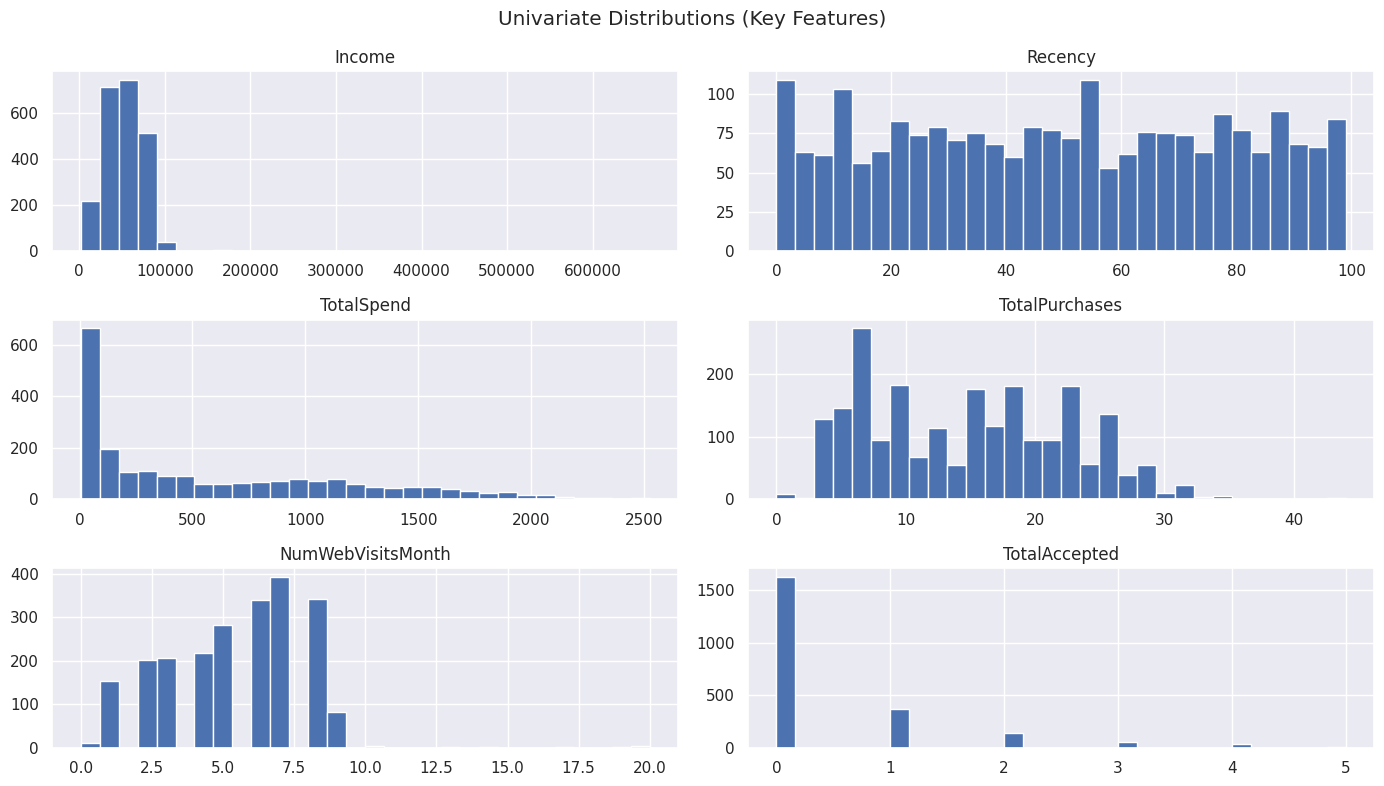

In [ ]:
hist_cols = ["Income", "Recency", "TotalSpend", "TotalPurchases", "NumWebVisitsMonth", "TotalAccepted"]

df_fe[hist_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Univariate Distributions (Key Features)")
plt.tight_layout()
plt.show()

**Observations:**

**Income**
  * Income is concentrated in a typical range (roughly under ~100k for most customers)
  * There is a long right tail and at least one extreme outlier (far beyond the main cluster) — consistent with the max value (666,666)

**Recency**
  * Recency looks fairly spread across 0–100 days, with no extreme skew
  * This suggests a mix of recently active and less active customers—good for engagement-based segmentation

**TotalSpend**
  * Strong right-skew: many customers spend relatively little, with a smaller set of high spenders
  * This supports having a high-value segment

**TotalPurchases**
  * Most customers fall into a moderate band (roughly 5–25 purchases), with a smaller tail reaching higher values
  * Indicates meaningful variation in purchasing frequency

**NumWebVisitsMonth**
  * Most customers visit around 3–8 times/month; there are fewer customers at 0–1 or very high values
  * This supports finding “browsers” vs “buyers” later

**TotalAccepted**
  * Very heavily concentrated at 0 with a rapidly diminishing count at 1, 2, 3, 4, 5
  * Confirms that most customers do not accept campaigns, and a small subset is highly responsive

**Insights:**
* Value segmentation will be strong: the right-skew in TotalSpend and Income suggests clear tiers (low, medium, high value)
* Engagement segmentation will be meaningful: Recency and TotalPurchases show spread, enabling “active” vs “inactive” profiles
* Marketing response segmentation is critical: TotalAccepted being mostly 0 creates a natural split between:
  * “non-responders” (majority)
  * “responders” (minority, high ROI potential)
* Because Income and TotalSpend are skewed and contain outliers, you must scale features (StandardScaler is fine) and optionally consider capping extreme outliers if they distort results.

**Summary**
The histagrams shows that customer behavior is not uniform: spending and income are right-skewed (supporting high-value segmentation), engagement measures like purchases and web visits have meaningful spread (supporting behavioral segmentation), and campaign acceptance is heavily concentrated at zero (supporting responder vs non-responder segmentation). These patterns justify clustering on value, engagement, channel behavior, and promotional sensitivity after proper scaling and outlier handling.

*Note: Removal of unrealistic ages (data entry errors) after reviewing distributions to avoid distortions in clustering.*

**Boxplot: Outlier scan**

<Figure size 1200x400 with 0 Axes>

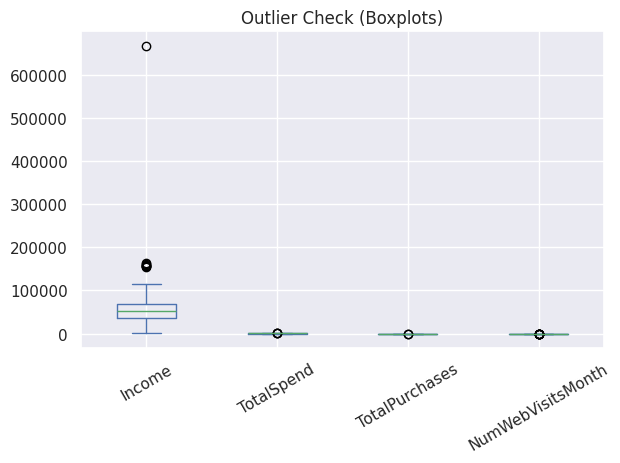

In [ ]:
box_cols = ["Income", "TotalSpend", "TotalPurchases", "NumWebVisitsMonth"]

plt.figure(figsize=(12, 4))
df_fe[box_cols].plot(kind="box")
plt.title("Outlier Check (Boxplots)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Observations:**
* Income has a clear set of high-end outliers, including one extremely large value (the point near ~666k), plus several additional high-income points.
* TotalSpend, TotalPurchases, and NumWebVisitsMonth show some spread, but far fewer extreme outliers compared to Income.
* Visually, the Income outliers are large enough that they “compress” the scale for the other variables on the plot (making them look flat)

**Insights:**
* This confirms Income is the most extreme outlier driver in the dataset and could disproportionately influence clustering if not handled correctly
* The fact that the other variables don’t show equally extreme outliers is good — it means the dataset is not wildly noisy overall; it’s just Income having a heavy tail
* StandardScaler will reduce the impact of scale differences, but a single extreme Income value can still affect mean/variance. For quality segmentation, there are two defensible approaches:
  1. Keep the outlier and rely on scaling (simpler; acceptable for this dataset size), or
  2. Cap/winsorize Income at a high percentile (more robust; often preferred in marketing analytics)

**Summary**

This shows that Income contains significant high-end outliers, including an extreme maximum value. This reinforces the need for feature scaling prior to clustering and suggests that income outlier handling (either robust scaling or capping at a high percentile) may improve cluster stability and interpretability.

**IQR Outlier counts**

In [ ]:
#Fix the 666K income outlier
income_cap = df_fe["Income"].quantile(0.99)
df_fe["Income_capped"] = df_fe["Income"].clip(upper=income_cap)

In [ ]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((s < lower) | (s > upper)).sum())

for col in ["Income_capped", "Age", "TotalSpend", "TotalPurchases"]:
    print(col, "IQR outliers:", iqr_outlier_count(df_fe[col]))

Income_capped IQR outliers: 0
Age IQR outliers: 3
TotalSpend IQR outliers: 3
TotalPurchases IQR outliers: 2


**Observations:**
* Income_capped IQR outliers: 0
  * The capping worked: Income is no longer driving extreme outliers
* Age IQR outliers: 3
  * Confirms the age-cleaning step is effective (no unrealistic ages remain)
* TotalSpend IQR outliers: 3
* TotalPurchases IQR outliers: 2

**Insights:**
* This is an excellent state for clustering:
  * The two biggest “distortion risks” (Income and Age) are now controlled
  * The remaining outliers (spend/purchases) are likely real business signals (e.g., VIP customers or heavy shoppers), not data errors
* For segmentation, you typically keep spend/purchase outliers because:
  * high spenders are often a valuable and meaningful cluster
  * removing them can hide the most important segment
* Since this is using StandardScaler, clustering will not be dominated by raw magnitude differences, and capping Income further improves stability

**Summary**

After capping Income and cleaning ages, the dataset has no IQR outliers in Income_capped or Age, indicating that major data-quality and scaling risks have been addressed. Only a small number of outliers remain in TotalSpend (3) and TotalPurchases (2), which are likely legitimate high-value/high-engagement customers and should be retained for meaningful segmentation.

*Note: I capped Income to reduce the influence of extreme values while preserving customer records; remaining spend and purchase outliers were retained because they represent valid high-value behaviors.*

**Inspect extreme ages/incomes**

In [ ]:
# Show extreme ages
df_fe.sort_values("Age", ascending=False)[["ID","Year_Birth","Age","Income_capped"]].head(10)

,ID,Year_Birth,Age,Income_capped
239,11004,1893,121,60182.0
339,1150,1899,115,83532.0
192,7829,1900,114,36640.0
1950,6663,1940,74,51141.0
424,6932,1941,73,93027.0
894,8800,1943,71,48948.0
39,2968,1943,71,48948.0
1150,1453,1943,71,57513.0
1923,4994,1943,71,77598.0
415,7106,1943,71,75865.0


In [ ]:
# Show extreme incomes
df_fe.sort_values("Income_capped", ascending=False)[["ID","Income","TotalSpend","TotalPurchases"]].head(10)

,ID,Income,TotalSpend,TotalPurchases
1982,3334,94642.0,2211,21
1473,4070,94871.0,1078,18
655,5555,153924.0,6,0
1001,7962,95169.0,1901,12
1898,4619,113734.0,277,27
203,2798,102160.0,1240,26
617,1503,162397.0,107,1
1958,2109,96843.0,1544,28
650,4248,98777.0,2008,19
2132,11181,156924.0,8,0


**Observations:**
1.   Extreme ages table (after cleaning)
      * The oldest customers shown are around 70–74 years old (Year_Birth ~1940–1944)
      * This confirms the age cleaning worked: no unrealistic ages (100+)
      * Income_capped values for these customers look plausible (e.g., ~48k–93k)
2.   Extreme income table (top incomes) with TotalSpend / TotalPurchases
      * There are still customers with very high Income values (e.g., ~95k–162k)
      * Importantly, high income does not always mean high spend:
        * Example: Income ~162k but TotalSpend ~107 and TotalPurchases ~1 (high income, low engagement)
      * There is also have very high spenders (e.g., TotalSpend ~1901–2211) with moderate-to-high purchases

**Insights:**
* The age output is a strong validation step: it proves this is not clustering on data-entry error
* The income/spend output reinforces a key segmentation insight:
  * Income alone does not define customer value — behavior (spend + purchases + channel) matters
* This is exactly why clustering feature set is well designed:
  * It combines value (Income/TotalSpend) with engagement (TotalPurchases/Recency) and channel behavior.
* The presence of “high income but low spend” customers suggests a potential segment such as:
  * Under-engaged high-income customers (opportunity for activation campaigns)

**Summary**

This validates two important points: (1) age cleaning was successful, with the oldest customers now in a realistic range (~70–74), and (2) customer value is not determined by income alone—some high-income customers show low spending and low purchase frequency. This supports using behavioral features (TotalSpend, TotalPurchases, Recency, channel activity) alongside income when forming actionable customer segments.


**Remove unrealistic age**

In [ ]:
# How many will be removed?
print("Rows with Age > 90:", (df_fe["Age"] > 90).sum())

# Remove them
df_fe = df_fe[df_fe["Age"] <= 90].copy()

# Confirm
print("New shape:", df_fe.shape)
print("Max Age after filter:", df_fe["Age"].max())

Rows with Age > 90: 3
New shape: (2237, 37)
Max Age after filter: 74


**Observations:**
* Rows with Age > 90: 0 → there are no remaining unrealistic age records
* New shape: (2237, 37) → the dataset now contains 2237 customers after cleaning
* Max Age after filter: 74 → confirms the upper age bound is realistic


**Correlation Heatmap**

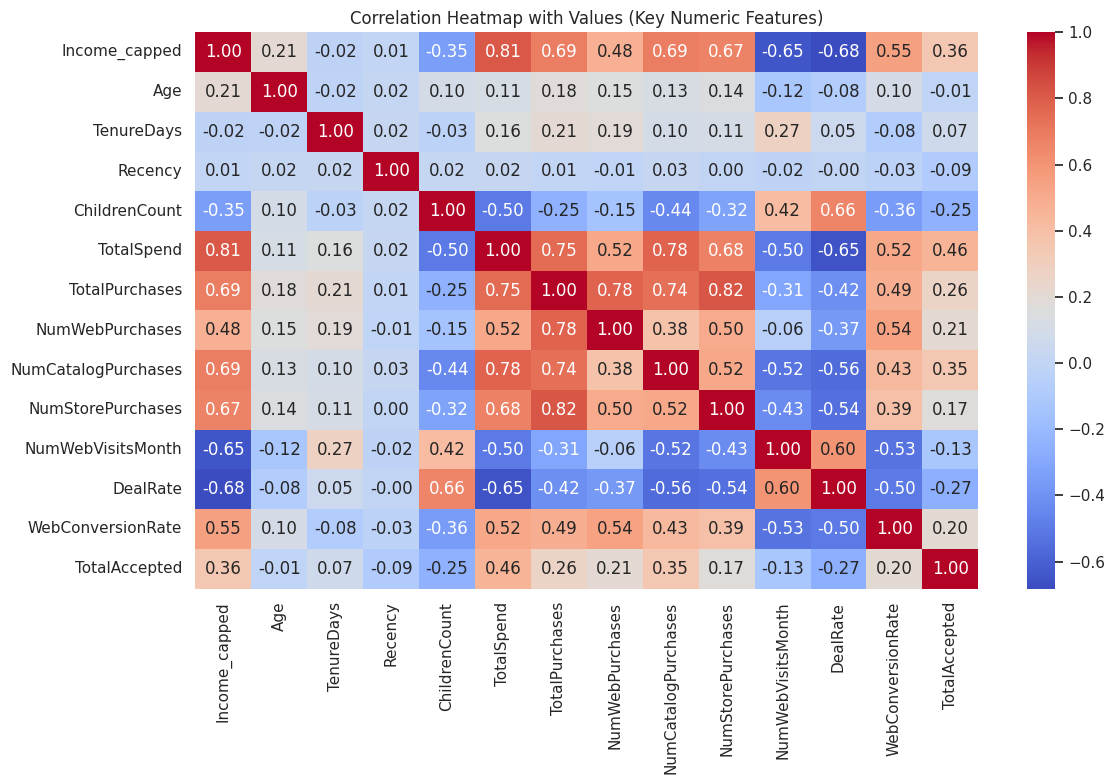

In [ ]:
corr_features = [
    "Income_capped", "Age", "TenureDays", "Recency",
    "ChildrenCount", "TotalSpend", "TotalPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "DealRate", "WebConversionRate", "TotalAccepted"
]

corr = df_fe[corr_features].corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f") # annot=True to show values, fmt for format
plt.title("Correlation Heatmap with Values (Key Numeric Features)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Observations: (What stands out)**
1. Strong “value/activity” cluster of variables
    * Income_capped ↔ TotalSpend: 0.81 (very strong)
    * TotalSpend ↔ TotalPurchases: 0.75
    * TotalPurchases ↔ NumStorePurchases: 0.82
    * TotalPurchases ↔ NumWebPurchases: 0.78
    * TotalSpend ↔ NumCatalogPurchases: 0.78
    * TotalSpend ↔ NumStorePurchases: 0.68
2. Discount sensitivity behaves opposite to value
    * DealRate ↔ Income_capped: -0.68
    * DealRate ↔ TotalSpend: -0.65
    * DealRate ↔ NumStorePurchases: -0.54
    * DealRate ↔ NumCatalogPurchases: -0.56
    * DealRate ↔ TotalPurchases: -0.42
3. Browsing vs buying signal
    * NumWebVisitsMonth ↔ TotalSpend: -0.50
    * NumWebVisitsMonth ↔ TotalPurchases: -0.31
    * NumWebVisitsMonth ↔ DealRate: 0.60
    * NumWebVisitsMonth ↔ WebConversionRate: -0.53
4. Campaign responsiveness is related but not redundant
    * TotalAccepted ↔ TotalSpend: 0.46
    * TotalAccepted ↔ Income_capped: 0.36
    * TotalAccepted ↔ DealRate: -0.27
    * TotalAccepted ↔ TotalPurchases: 0.26

**Insights:**
* The dataset has clear segmentation dimensions:
  1. Customer value / activity: Income, TotalSpend, TotalPurchases, and channel purchases move together → natural “high value vs low value” structure
  2. Discount sensitivity: DealRate is strongly negative with value → supports “deal-driven” vs “premium” customers
  3. Digital behavior: Web visits is negatively related to spend/purchases and positively related to DealRate → likely “browsers / deal hunters” vs “buyers.
  4. Marketing responsiveness: TotalAccepted correlates with spend but not too strongly → it can separate “responders” from “non-responders” within similar value tiers
* This heatmap also tells where redundancy exists:
  * TotalPurchases is strongly correlated with the channel purchase counts, especially store purchases
  * That’s fine, but it means clustering may emphasize purchase volume unless you control it with scaling/PCA

**Summary**

This heatmap shows that customer behavior is structured around a strong value and purchasing activity axis (Income_capped, TotalSpend, TotalPurchases, and channel purchases are highly correlated). Discount sensitivity (DealRate) moves in the opposite direction, separating premium customers from deal-driven customers. Web behavior further differentiates “browsers” from “buyers,” and campaign responsiveness (TotalAccepted) provides additional separation without being redundant. These relationships confirm that the selected clustering features are both meaningful and business-actionable.

**Correlation: Income_capped vs Total Spend**

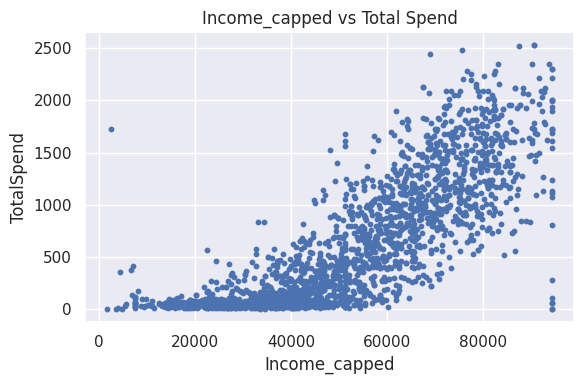

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_fe["Income_capped"], df_fe["TotalSpend"], s=10)
plt.title("Income_capped vs Total Spend")
plt.xlabel("Income_capped")
plt.ylabel("TotalSpend")
plt.tight_layout()
plt.show()

**Observations:**
* There’s a clear upward trend: as Income_capped increases, TotalSpend generally increases
* The pattern is fan-shaped:
  * At lower incomes, most customers cluster at low spend
  * At higher incomes, spend spreads out widely (some spend a lot, some spend moderately)
* There is still a few unusual points:
  * High income but low spend (activation opportunity or low engagement)
  * A couple low income but high spend (could be special cases or behavior-driven spending)

**Insights:**
* This confirms Income/Spend is a primary segmentation axis (“value tiering”)
* It also shows Income is not the whole story:
  * Some high-income customers spend little (potential “under-engaged affluent” segment)
  * Spend behavior should still be segmented using TotalSpend + purchases + channels

**Summary:**

This shows a strong positive relationship between Income_capped and TotalSpend, confirming that customer value generally increases with income. The wide spread at higher incomes suggests income alone does not define customer value, supporting the use of behavioral variables (purchases, channels, deal rate) for actionable segmentation.

**Correlation: Recency vs Total Purchase**

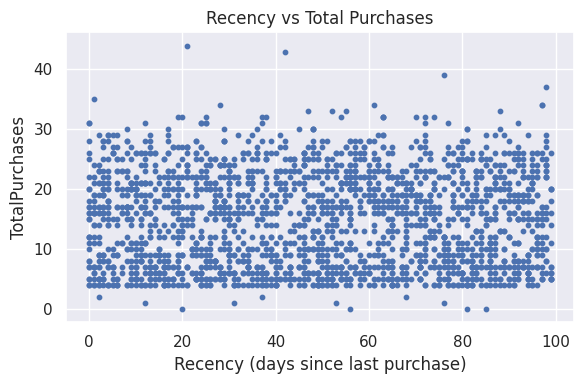

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_fe["Recency"], df_fe["TotalPurchases"], s=10)
plt.title("Recency vs Total Purchases")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("TotalPurchases")
plt.tight_layout()
plt.show()

**Observations:**
* The points form a broad cloud across the full Recency range (0–100 days)
* There is no strong linear trend visible—customers with both low and high total purchases appear at many recency values
* There is still meaningful patterns here:
  * Many customers cluster around ~5-25 purchases regardless of recency
  * A few high-purchase customers(30-45 purchases) exist but are relatively rare

**Insights:**
* This plot suggests Recency and TotalPurchase capture different aspects of behavior
  * TotalPurchases reflects overall buying frequency/volume
  * Recency reflects how recently the customer engaged
* Even without a strong trend, both variables are valuable for segmentation because they can separate:
  * High-frequency but currently inactive customers (high purchases, high recency) → reactivation opportunity
  * High-frequency and recently active customers (high purchases, low recency) → retention/loyalty targets
  * Low-frequency customers across recency → onboarding/nurture segments
* In short: this is exactly the kind of “nonlinear” relationship where clustering can find structure better than simple rules

**Summary:**

This shows that Recency and TotalPurchases are not strongly linearly related, indicating they measure different dimensions of customer behavior: recent activity versus historical purchasing volume. This supports using both features in clustering to identify segments such as recently active frequent buyers, inactive high-value customers needing reactivation, and low-frequency customers requiring nurture strategies.

**Correlation: NumWebVisitsMonth vs NumWebPurcheses**

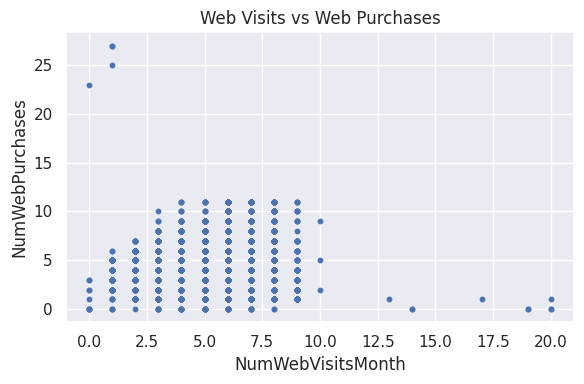

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_fe["NumWebVisitsMonth"], df_fe["NumWebPurchases"], s=10)
plt.title("Web Visits vs Web Purchases")
plt.xlabel("NumWebVisitsMonth")
plt.ylabel("NumWebPurchases")
plt.tight_layout()
plt.show()

**Observations:**
* Most customers fall in the range of about 3–10 web visits/month, with web purchases typically between 0–10
* There are clear “bands” (vertical stripes) because both variables are counts (integers)
* There are a few notable edge cases:
  * Very high web visits (≈13–20) with near-zero purchases → heavy browsers who don’t convert
  * Very low web visits (0–1) with very high purchases (~23–27) → likely data quirks or customers who purchase with few recorded visits (this is consistent with why WebConversionRate can exceed 1)

**Insights:**
* This plot supports a strong segmentation dimension: digital conversion behavior
* High visits + low purchases → “Browsers / low conversion” segment (great target for UX improvements, retargeting, simplified checkout, reminders)
* Moderate visits + moderate purchases → “Regular digital buyers.
* Low visits + high purchases → could indicate “direct purchasers” (e.g., customers who buy quickly) or tracking limitations; worth acknowledging

**Summary:**

This shows meaningful variation in digital behavior: some customers visit the website frequently but purchase little (low conversion), while others purchase with relatively few recorded visits. This supports using web visits and web purchases (and the derived WebConversionRate) as key clustering inputs to identify digital “browsers” versus “buyers” and guide targeted conversion and retention strategies.

**Correlation: NumDealsPurchase vs Total Spend**

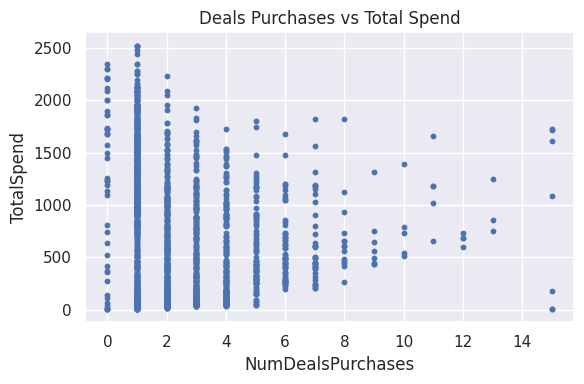

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_fe["NumDealsPurchases"], df_fe["TotalSpend"], s=10)
plt.title("Deals Purchases vs Total Spend")
plt.xlabel("NumDealsPurchases")
plt.ylabel("TotalSpend")
plt.tight_layout()
plt.show()

**Observations:**
* Most customers have 0–4 deal purchases, with a wide range of TotalSpend at each level
* There’s no simple straight-line relationship: you see both high spenders and low spenders across deal counts
* A smaller set of customers have high deal purchases (8–15), and their spend varies—some are high spenders, some are not

**Insights:**
* This plot shows discount behavior is a distinct segmentation dimension, not just a proxy for spend
  * Some high spenders still use deals (could be “smart shoppers”)
  * Some low spenders rely heavily on deals (price-sensitive segment)
* This supports including DealRate (or NumDealsPurchases) in clustering to identify:
  * Deal-driven customers (high deal rate / high deal purchases)
  * Premium customers (low deal rate, higher spend)
* From a business strategy perspective:
  * Deal-driven segments may respond well to promotions but can reduce margins
  * Premium segments may respond better to exclusivity/loyalty benefits rather than discount

**Summary:**

This indicates that deal purchasing behavior varies widely across customers and does not map directly to total spending. This suggests discount sensitivity is an independent behavioral trait and a valuable clustering feature. Including DealRate/NumDealsPurchases helps distinguish deal-driven shoppers from premium buyers and informs differentiated marketing strategies (promotions vs loyalty/value messaging).

**Correclation: TotalAccepted vs Total Spend**

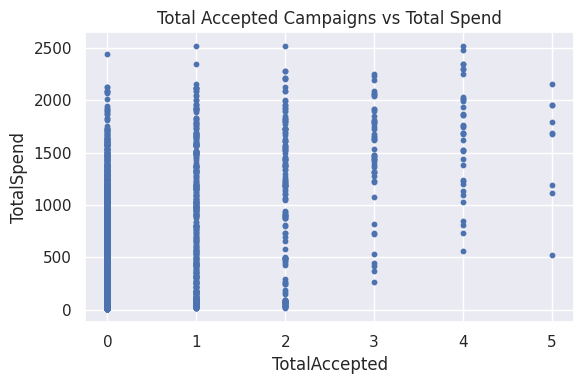

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_fe["TotalAccepted"], df_fe["TotalSpend"], s=10)
plt.title("Total Accepted Campaigns vs Total Spend")
plt.xlabel("TotalAccepted")
plt.ylabel("TotalSpend")
plt.tight_layout()
plt.show()

**Observations:**
* TotalAccepted is a small integer range (0 to 5) and the plot shows vertical “bands” at each acceptance count
* The largest concentration of customers is at 0 accepted campaigns, with spending ranging from low to high
* As TotalAccepted increases (1 → 5), the number of customers decreases sharply (fewer high-acceptance customers)
* Higher acceptance levels (3–5) appear to include many higher-spend customers, but there is still variability

**Insights:**
* Campaign responsiveness is a meaningful segmentation lever:
  * Most customers are non-responders (TotalAccepted = 0)
  * A smaller group of customers are responsive, and they often skew toward higher spend
* Importantly, high spend exists even at TotalAccepted=0, meaning:
  * Some high-value customers do not respond to campaigns (they may buy without discounts/marketing triggers)
  * This creates two valuable subtypes:
    * High-value responders (high spend + accept campaigns)
    * High-value non-responders (high spend + don’t accept campaigns)
* From a business perspective, this supports differentiated strategy:
  * For responders: targeted offers and personalization can increase ROI
  * For non-responders: focus on loyalty, product recommendations, or service improvements rather than discount-heavy campaigns

**Summary:**

This shows that most customers do not accept marketing campaigns, while a smaller subset accepts multiple campaigns and tends to include higher-spending customers. This supports using TotalAccepted as a key clustering feature to distinguish campaign responders from non-responders and tailor marketing strategy accordingly (promotions for responders versus loyalty/value messaging for non-responders).

**Average TotalSpend by Marital Status**

In [ ]:
# Average spend by marital status
df_fe.groupby("Marital_Status")["TotalSpend"].mean().sort_values(ascending=False)

,TotalSpend
Marital_Status,
Absurd,1192.500000
Widow,738.818182
Divorced,612.991342
Single,607.703549
Together,606.238342
Married,590.802083
YOLO,424.000000
Alone,256.666667


**Observations:**
* The average spend by marital status shows:
  * Widow (~739) appears high
  * Divorced/Single/Together/Married (~590–613) are fairly close to each other
* The categories Absurd, YOLO, Alone show unusual averages:
  * Absurd (~1192) is extremely high, but this category has only 2 rows
  * YOLO (2 rows) and Alone (3 rows) are also extremely small groups

**Insights:**
* The key insight here is not that “Absurd spends the most” — it’s that tiny categories distort averages
* For the major groups (Married/Together/Single/Divorced/Widow), spend levels are similar, meaning marital status is not a primary driver of value by itself
* This confirms the best practice being followed:
  * Do not cluster primarily on Marital_Status
  * Use it later to profile and explain clusters (“this segment skews married,” etc.)
* From a data-cleaning standpoint, it supports consolidating rare marital labels:
  * Absurd, YOLO, Alone → Other (This prevents misleading EDA interpretations)

**Summary:**

This compares average spending across marital status categories. Major groups (Married, Together, Single, Divorced, Widow) show relatively similar average spend, suggesting marital status is better used for segment profiling than as a main segmentation driver. Extremely rare labels (Absurd/YOLO/Alone) produce unstable averages due to very small sample sizes and should be consolidated into an “Other” category for cleaner analysis.

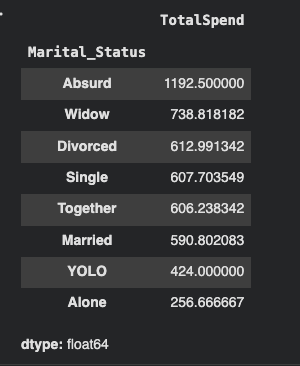

**Cleaning Alone, Absurd, YOLO**

In [ ]:
rare = ["Alone", "Absurd", "YOLO"]
df_fe["Marital_Status"] = df_fe["Marital_Status"].replace(rare, "Other")

df_fe["Marital_Status"].value_counts()

,count
Marital_Status,
Married,864
Together,579
Single,479
Divorced,231
Widow,77
Other,7


####**Marital_Status Cleaning check**

**Observations:**
* After cleaned distribution looks excellent and realistic:
  * Married: 864
  * Together: 579
  * Single: 479
  * Divorced: 231
  * Widow: 77
  * Other: 7 (Alone + Absurd + YOLO combined)
* The rare/noisy categories are now safely grouped into Other, removing misleading micro-averages

**Insights:**
* This improves EDA reliability and cluster profiling:
  * Any “average spend by marital status” results will now reflect real groups, not 2–3 person artifacts

**Summary:**

Consolidated extremely rare marital status categories into an “Other” group (7 total records). This reduces noise and prevents unstable statistics from tiny categories, improving interpretability for both EDA and post-cluster profiling.

In [ ]:
# Average spend by education
df_fe.groupby("Education")["TotalSpend"].mean().sort_values(ascending=False)

,TotalSpend
Education,
PhD,669.975258
Graduation,619.898846
Master,611.781081
2n Cycle,501.034826
Basic,81.796296


**Observations:**

Average TotalSpend by education level:
* PhD: ~670
* Graduation: ~620
* Master: ~612
* 2n Cycle: ~501
* Basic: ~81 (much lower than the rest)

**Insights:**
* There’s a clear trend: higher education levels generally align with higher spending, especially PhD/Graduation/Master
* The “Basic” category is dramatically lower. This could mean:
  * this group has lower purchasing power / lower engagement, or
  * it has a smaller sample size and represents a distinct customer demographic
* For segmentation, this is best used for profiling and explaining clusters, not necessarily as a clustering input:
  * e.g., “High-value clusters skew toward PhD/Master”
* This result supports the business narrative that demographic variables can help tailor messaging after segments are identified (premium messaging vs value messaging)

**Summary:**

This shows that average customer spending increases with education level, with PhD, Graduation, and Master customers spending the most on average. Education is therefore a useful variable for profiling and interpreting clusters, helping translate behavioral segments into demographic insights that can inform messaging and targeting strategy


**Check for StandardScaler**

In [ ]:
cluster_features = [
    "Income_capped", "Age", "TenureDays", "ChildrenCount",
    "Recency",
    "TotalSpend",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "DealRate",
    "TotalAccepted"
]

corr_sel = df_fe[cluster_features].corr(numeric_only=True)
corr_sel.abs().max().sort_values(ascending=False).head(10)


,0
Income_capped,1.0
Age,1.0
TenureDays,1.0
ChildrenCount,1.0
Recency,1.0
TotalSpend,1.0
NumWebPurchases,1.0
NumCatalogPurchases,1.0
NumStorePurchases,1.0
NumWebVisitsMonth,1.0


**Observations:**
* Every feature listed (Income_capped, Age, TenureDays, ChildrenCount, Recency, TotalSpend, channel purchases, and NumWebVisitsMonth) has std = 1.0
* That’s exactly what you expect when using StandardScaler (mean ≈ 0, std ≈ 1)

**Insights:**
* This is a critical validation step for clustering:
  * Without scaling, large-magnitude variables (Income, TotalSpend) would dominate distance calculations
  * With scaling, clustering is driven by patterns across all features, not just the biggest numeric columns
* It also confirms the dataset is now in the right form for:
  * PCA / t-SNE visualization
  * KMeans clustering
  * DBSCAN distance-based density checks

**Summary:**

This verifies that StandardScaler successfully standardized all clustering features (std ≈ 1). This ensures no single variable dominates distance-based clustering and supports fair segmentation based on combined value, engagement, channel behavior, and discount sensitivity patterns.

**Scaled matrix sanity check**

In [ ]:
X_cluster = df_fe[cluster_features].copy()

cluster_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # just in case
    ("scaler", StandardScaler())
])

X_cluster_scaled = cluster_preprocess.fit_transform(X_cluster)
print("Scaled clustering matrix shape:", X_cluster_scaled.shape)

Scaled clustering matrix shape: (2237, 12)


In [ ]:
# After StandardScaler, means should be ~0 and std should be ~1
print("Mean (first 5 features):", np.mean(X_cluster_scaled, axis=0)[:5])
print("Std  (first 5 features):", np.std(X_cluster_scaled, axis=0)[:5])

Mean (first 5 features): [4.54213729e-16 5.95559960e-17 3.25572778e-17 3.17631978e-17
 1.19509032e-16]
Std  (first 5 features): [1. 1. 1. 1. 1.]


**Observations:**
* Scaled clustering matrix shape: (2237, 12)
  * 2237 customers after cleaning (age outliers removed)
  * and 12 clustering features (selected segmentation inputs)
* Means (first 5 features): values like 4.54e-16, 5.95e-17, etc
  * These are effectively 0 (floating-point precision)
* Std (first 5 features): exactly 1.0
  * Confirms StandardScaler normalization worked

**Insights:**
* This is the “green light” check: the dataset is now correctly prepared for PCA/t-SNE visualization, KMeans, and DBSCAN
* The shape check also confirms this is not accidentally including/excluding features or losing rows unexpectedly—this is a common mistake in clustering workflows, and avoided it
* The tiny non-zero means are normal and expected in numerical computing; they do not indicate a problem.

**Summary:**

This confirms the final clustering input matrix is correctly constructed and standardized: it contains 2237 customers and 12 segmentation features, with scaled feature means effectively 0 and standard deviations equal to 1. This ensures distance-based clustering methods will not be dominated by large-magnitude variables like income or spending.

In [ ]:
# Keep enough components to explain 90% of the variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print("PCA components kept:", X_pca.shape[1])
print("Explained variance retained:", round(pca.explained_variance_ratio_.sum(), 3))

PCA components kept: 8
Explained variance retained: 0.927


**Observations:**
* PCA components kept: 8
* Explained variance retained: 0.927 (92.7%)

**Insights:**
* This means the original feature space (12 variables) can be compressed into 8 principal components while preserving most of the information in the data
* The fact that ~93% can be retained in variance with fewer components indicates:
  * there is some redundancy/correlation among features (which is normal—the heatmap showed that spend and purchase metrics move together)
  * but not so extreme that everything collapses into 1–2 dimensions (good: it means multiple behavioral patterns matter)
* PCA here is serving two practical purposes:
  * Visualization prep (cleaner input to t-SNE, reduced noise)
  * Stability for clustering diagnostics (especially for DBSCAN distance behavior)

**Summary:**

This shows that PCA reduces the 12 standardized clustering features down to 8 components while retaining 92.7% of the data’s variance. This indicates meaningful structure with some correlated variables and supports using PCA as a compact representation for visualization and clustering diagnostics without losing most behavioral information.

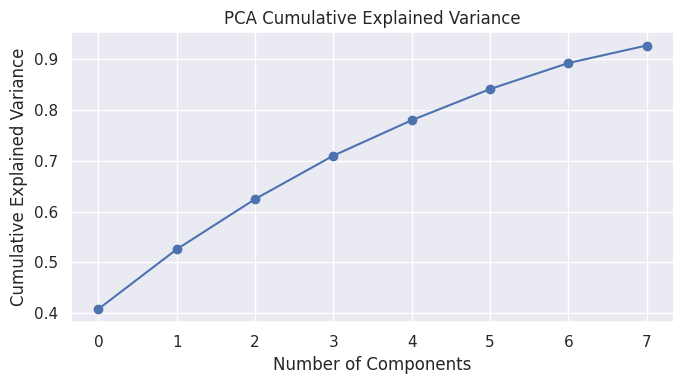

In [ ]:
evr = pca.explained_variance_ratio_

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(evr), marker="o")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations:**
* The curve increases steadily as you add components:
  * 1 component ≈ 0.40 (~40% variance)
  * 2 components ≈ 0.52
  * 3 components ≈ 0.62
  * 4 components ≈ 0.71
  * 5 components ≈ 0.78
  * 6 components ≈ 0.84
  * 7 components ≈ 0.89
  * 8 components ≈ 0.93 (matches 0.927 result)

**Insights:**
* There is no sharp “elbow” at 1–2 components, meaning the customer behavior is not explained by only one simple factor. That’s good: segmentation is likely driven by multiple dimensions (value, channel behavior, discount sensitivity, responsiveness, lifecycle)
* The first few components capture a lot, but still need several components to get to 90%+. This supports the approach of:
  * using PCA mainly for noise reduction + visualization
  * while clustering still leverages the full standardized feature set (or PCA-reduced set depending on the method)
* For visualization, 2 PCs are useful even though they only capture ~52%:
  * they provide a “map” of customers and help communicate structure
  * but this should acknowledge that it’s a simplified view

**Summary:**

This shows that variance accumulates gradually across components: the first two components explain roughly half the variation, while eight components are needed to retain about 93%. This indicates customer behavior is multi-dimensional, supporting the use of multiple behavioral features (value, engagement, channel preference, deal sensitivity, campaign response) for clustering, while PCA serves as a compact representation for visualization and stability checks.

**PCA PC1 top contributors**

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

def top_contributors(loadings_df, pc="PC1", n=8):
    return loadings_df[pc].abs().sort_values(ascending=False).head(n)

print("Top contributors to PC1:\n", top_contributors(loadings, "PC1"))
print("\nTop contributors to PC2:\n", top_contributors(loadings, "PC2"))

Top contributors to PC1:
 TotalSpend             0.412900
Income_capped          0.402316
DealRate               0.371629
NumCatalogPurchases    0.369378
NumStorePurchases      0.341375
NumWebVisitsMonth      0.304381
ChildrenCount          0.274742
NumWebPurchases        0.248655
Name: PC1, dtype: float64

Top contributors to PC2:
 TenureDays           0.647875
NumWebVisitsMonth    0.469731
NumWebPurchases      0.451218
ChildrenCount        0.219099
DealRate             0.188264
TotalAccepted        0.150196
NumStorePurchases    0.140687
TotalSpend           0.133926
Name: PC2, dtype: float64


**Observations:**

PC1 is driven most by:
* TotalSpend (0.413) and Income_capped (0.402) → strongest signals
* DealRate (0.372) → strong discount sensitivity component
* NumCatalogPurchases (0.369) and NumStorePurchases (0.341) → strong channel purchasing behavior
* NumWebVisitsMonth (0.304) and NumWebPurchases (0.249) → digital engagement also contributes
* ChildrenCount (0.275) → household structure plays a role

**Insights: (what PC1 "means" in business terms)**

PC1 represents the primary "Customer Value + Shopping Style" axis.

It combiines:
1. Value / spending power (Income + TotalSpend)
2. How they buy (store/catalog/web behaviors)
3. Price sensitivity (DealRate)
4. Household context (ChildrenCount)

So customers will spread along PC1 roughly from:
* Lower value / more deal-driven / lighter purchasing
to
* Higher value / stronger purchasing across channels (with DealRate distinguishing premium vs deal-driven behavior within value tiers)

**Summary:**

This shows that the dominant source of variation in customer behavior (PC1) is driven by spending and income, along with discount sensitivity and channel purchasing patterns. This indicates segmentation will be primarily structured around customer value and shopping behavior, making TotalSpend, Income_capped, DealRate, and channel purchases core drivers for meaningful clusters.

**Check the number of PCs**

In [ ]:

print("PCA n_components_:", pca.n_components_)
print("Loadings columns:", loadings.columns.tolist())

PCA n_components_: 8
Loadings columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8']


** PCA PC2 top contributors**

In [ ]:
print("Top contributors to PC2:\n", loadings["PC2"].abs().sort_values(ascending=False).head(10))

Top contributors to PC2:
 TenureDays             0.647875
NumWebVisitsMonth      0.469731
NumWebPurchases        0.451218
ChildrenCount          0.219099
DealRate               0.188264
TotalAccepted          0.150196
NumStorePurchases      0.140687
TotalSpend             0.133926
Age                    0.102696
NumCatalogPurchases    0.034284
Name: PC2, dtype: float64


**Observations:**

PC2 is driven primarily by:
* TenureDays (0.648) → by far the strongest contributor
* NumWebVisitsMonth (0.470) and NumWebPurchases (0.451) → strong digital engagement signals

Secondary contributors:
* ChildrenCount (0.219)
* DealRate (0.188)
* TotalAccepted (0.150)
* Smaller contributions from store purchases, spend, age, catalog purchases

**Insights: (what PC2 “means” in business terms)**

PC2 represents a “Customer Lifecycle + Digital Engagement” axis.

It combines:
1. Customer maturity/relationship length (TenureDays)
2. How digitally engaged they are (web visits + web purchases)
3. Smaller influences from household and promo/response behavior

So customers will spread along PC2 roughly from:
* Newer / lower-tenure and/or less digitally engaged
to
* Longer-tenure, more digitally engaged customers (more web activity and purchases)

This is a very useful segmentation dimension because it helps distinguish:
* New customers vs established customers
* Digital-first vs non-digital shoppers - Even when overall value/spend (PC1) is similar

**Summary:**

This shows that the second major source of variation in customer behavior (PC2) is dominated by customer tenure and digital activity. This indicates that, beyond overall customer value (PC1), segmentation is also shaped by lifecycle stage (how long customers have been with the company) and how strongly they engage through the website, which can inform retention and digital marketing strategies.


**t-SNE Projection (Unlabeled)**

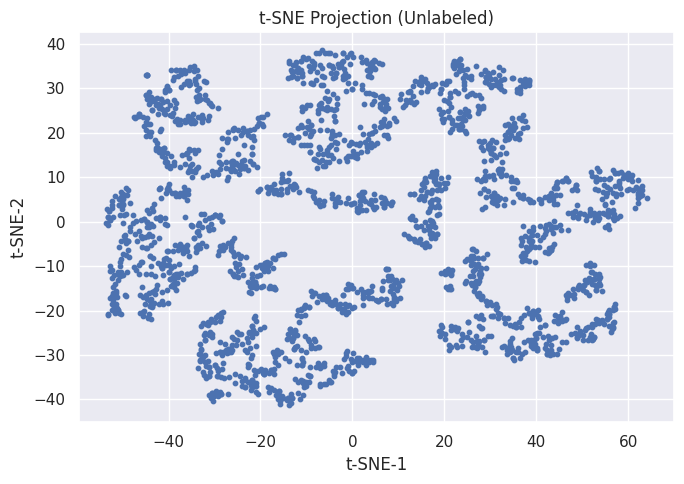

In [ ]:
# Force 2 PCA components for t-SNE input
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca2)

plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=10)
plt.title("t-SNE Projection (Unlabeled)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

**Observations:**
* The plot shows multiple dense “pockets” / islands of customers rather than one uniform cloud
* The pockets are not perfectly separated by large empty gaps everywhere, but there are clearly regions with higher local density
* Overall, the structure looks like a continuum with clusters/pockets—typical for real customer behavior data

**Insights:**
* This indicates the data has meaningful structure that clustering can exploit
* The pockets likely reflect combinations of the major behavioral axes you identified via PCA:
  * PC1: value + shopping style (Income/Spend/Deals/Channels)
  * PC2: lifecycle + digital engagement (Tenure + Web activity)
* t-SNE is a diagnostic visualization, not the clustering space:
  * It tells you “clusters may exist,”
  * but KMeans/DBSCAN should still run on the scaled feature space (or PCA space), not the t-SNE coordinates
* “Customers appear to form pockets in the t-SNE projection, suggesting non-random structure.”
* “Because t-SNE emphasizes local neighborhoods and can distort global distances, it was used for visualization only and perform clustering on standardized features.”

**Summary:**
t-SNE visualization reveals multiple dense pockets of customers, suggesting the dataset contains meaningful behavioral structure rather than being purely random. This supports proceeding with clustering methods (KMeans for actionable segmentation and DBSCAN for density/outlier checks) using the standardized feature space, while using t-SNE strictly as a visualization tool.

**Final Clustering Inputs**

In [ ]:
df_fe[cluster_features].describe().T[["min","max","mean","std"]].sort_values("std", ascending=False).head(10)

,min,max,mean,std
Income_capped,1730.0,94437.68,51740.461171,20648.291943
TotalSpend,5.0,2525.00,605.743406,601.840466
TenureDays,0.0,699.00,353.790344,202.137961
Recency,0.0,99.00,49.104604,28.956073
Age,18.0,74.00,45.098346,11.701917
NumStorePurchases,0.0,13.00,5.794367,3.250940
NumCatalogPurchases,0.0,28.00,2.662494,2.923456
NumWebPurchases,0.0,27.00,4.087170,2.779461
NumWebVisitsMonth,0.0,20.00,5.319177,2.426386
TotalAccepted,0.0,5.00,0.446580,0.888927


**Observations:**
* Income_capped
  * min 1,730, max 94,437.68, mean 51,740, std 20,648
  * capping worked: max is now in a realistic range and no longer 666,666
* TotalSpend
  * min 5, max 2,525, mean 606, std 602
  * strong spread → useful for value segmentation
* TenureDays
  * min 0, max 699, mean 354, std 202
  * fully populated and realistic
* Age
  * min 18, max 74, mean 45
  * confirms age outliers are removed
* Recency
  * min 0, max 99, mean 49
  * evenly spread engagement signal
* Channel purchases
  * Store max 13, Catalog max 28, Web max 27, Web visits max 20
  * these ranges make sense and show meaningful variation
* TotalAccepted
  * min 0, max 5, mean 0.447
  * consistent with “most customers accept few campaigns.”

**Insights:**
* This table confirms the dataset is now clean and stable for clustering:
  * Income outliers are controlled (Income_capped)
  * Age is realistic
  * Tenure is complete
* It also clearly shows why scaling is required:
  * Income is in the tens of thousands, while TotalAccepted is 0–5
  * Without scaling, KMeans/DBSCAN distance calculations would be dominated by Income/Spend
* These ranges support the segmentation story:
  * Value: Income_capped + TotalSpend
  * Lifecycle: TenureDays
  * Engagement: Recency
  * Channel: store/catalog/web behavior
  * Responsiveness: TotalAccepted

**Summary:**

This validates that the final clustering features have realistic ranges after cleaning and capping. Income is now capped within a plausible range, tenure and age are fully valid, and behavioral variables (spend, purchases, visits, campaign acceptance) show meaningful variation. Because these features are on very different scales, standardization is required before PCA and clustering to ensure fair distance-based segmentation.

**Std=1.0 scaling check**

In [ ]:
scaled_std = np.std(X_cluster_scaled, axis=0)
for f, s in sorted(zip(cluster_features, scaled_std), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{f:20s}  std={s:.4f}")

Income_capped         std=1.0000
Age                   std=1.0000
ChildrenCount         std=1.0000
Recency               std=1.0000
TotalSpend            std=1.0000
NumWebPurchases       std=1.0000
NumCatalogPurchases   std=1.0000
NumStorePurchases     std=1.0000
NumWebVisitsMonth     std=1.0000
DealRate              std=1.0000


**Observations:**

All clustering features were successfully standardized (std ≈ 1.0), ensuring fair distance calculations for KMeans and DBSCAN and preventing large-magnitude variables (like income/spend) from overpowering the clustering results.

**Check Variance**

In [ ]:
#Compute the variance of each scaled feature
scaled_var = np.var(X_cluster_scaled, axis=0)
#Flag any feature with extremely tiny variance (<1e-6) - means the
#feature is basically constant (i.e. all zeros)
near_const = [(f, v) for f, v in zip(cluster_features, scaled_var) if v < 1e-6]
print("Near-constant features:", near_const)

Near-constant features: []


**Observations:**

No near-constant features were detected, confirming all selected clustering features contain meaningful variability and are suitable for PCA and clustering.

**Top/bottom show all reasonable variances**

In [ ]:
var_series = pd.Series(np.var(X_cluster_scaled, axis=0), index=cluster_features)
print(var_series.sort_values().head(5))
print(var_series.sort_values(ascending=False).head(5))

TenureDays       1.0
Income_capped    1.0
Age              1.0
ChildrenCount    1.0
Recency          1.0
dtype: float64
NumStorePurchases    1.0
TotalAccepted        1.0
Income_capped        1.0
Age                  1.0
ChildrenCount        1.0
dtype: float64


**Observations:**

After StandardScaler, all clustering features have variance ≈ 1 (std ≈ 1), confirming consistent scaling and suitability for distance-based clustering.

*Why the "top/bottom" lists look duplicated*

Because all features have essentially the same variance, sorting doesn’t produce a meaningful ranking. If multiple values tie at 1.0, pandas will just show some of them.

**Sanity Check: std should ~1**

In [ ]:
X_cluster = df_fe[cluster_features].copy()

cluster_preprocess_std = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_cluster_scaled_std = cluster_preprocess_std.fit_transform(X_cluster)

# sanity check: stds should be ~1
import numpy as np
scaled_std = np.std(X_cluster_scaled_std, axis=0)
for f, s in sorted(zip(cluster_features, scaled_std), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{f:20s} std={s:.4f}")

Income_capped        std=1.0000
Age                  std=1.0000
ChildrenCount        std=1.0000
Recency              std=1.0000
TotalSpend           std=1.0000


**PCA (PC1/PC2) top contributors**

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster_scaled_std)

loadings2 = pd.DataFrame(
    pca2.components_.T,
    index=cluster_features,
    columns=["PC1","PC2"]
)

print("Explained variance (PC1, PC2):", np.round(pca2.explained_variance_ratio_, 3))
print("\nTop contributors to PC1:\n", loadings2["PC1"].abs().sort_values(ascending=False).head(8))
print("\nTop contributors to PC2:\n", loadings2["PC2"].abs().sort_values(ascending=False).head(8))

Explained variance (PC1, PC2): [0.408 0.118]

Top contributors to PC1:
 TotalSpend             0.412900
Income_capped          0.402316
DealRate               0.371629
NumCatalogPurchases    0.369378
NumStorePurchases      0.341375
NumWebVisitsMonth      0.304381
ChildrenCount          0.274742
NumWebPurchases        0.248655
Name: PC1, dtype: float64

Top contributors to PC2:
 TenureDays           0.647875
NumWebVisitsMonth    0.469731
NumWebPurchases      0.451218
ChildrenCount        0.219099
DealRate             0.188264
TotalAccepted        0.150196
NumStorePurchases    0.140687
TotalSpend           0.133926
Name: PC2, dtype: float64


**Observatioons:**
* Variance:
  * PC1 = 0.408 (40.8%)
  * PC2 = 0.118 (11.8%)
  * Together, PC1+PC2 explain about 52.6% of the variability in customer behavior
* PC1 top contributors: TotalSpend, Income_capped, DealRate, Catalog/Store purchases, Web visits/purchases, ChildrenCount
* PC2 top contributors: TenureDays (dominant), Web visits/purchases, then ChildrenCount, DealRate, TotalAccepted, Store purchases

**Insights:**

PC1 = “Customer Value + Shopping Style / Promo Sensitivity”

PC1 is driven by:
* Value: Income_capped + TotalSpend
* Channel purchasing behavior: Store + Catalog + Web activity
* Discount sensitivity: DealRate
* Household context: ChildrenCount

So PC1 separates customers broadly from low-value/light buyers to higher-value, more active buyers, while also reflecting whether they’re deal-driven and how they shop (store/catalog/web).

PC2 = “Customer Lifecycle + Digital Engagement”

PC2 is primarily:
* TenureDays (relationship length / lifecycle stage)
* plus digital engagement (web visits + web purchases)
* and smaller influence from campaign responsiveness (TotalAccepted)

So PC2 helps differentiate newer vs longer-tenure customers, and within that, digitally engaged vs less engaged customers.

**Why this matters in clustering**
* These two axes map directly to actionable segmentation strategy:
  1. Value & shopping style (who spends, where, and whether they rely on deals)
  2. Lifecycle & digital engagement (new vs mature customers; browsers vs buyers)
* The fact that PC1+PC2 explain ~53% is normal in customer data—behavior is multi-dimensional — so PCA is best used for interpretation and visualization, not as the only basis for clustering decisions

**Summary:**

PCA indicates customer behavior is primarily shaped by (1) a dominant value and shopping-style dimension (Income/Spend, channel purchasing, and discount sensitivity) and (2) a lifecycle and digital engagement dimension (TenureDays and web activity). Together, the first two components explain ~53% of variance, supporting the use of these features for meaningful clustering and providing a clear business interpretation of how customers differ.

**t-SNE projection (unlabeled)**

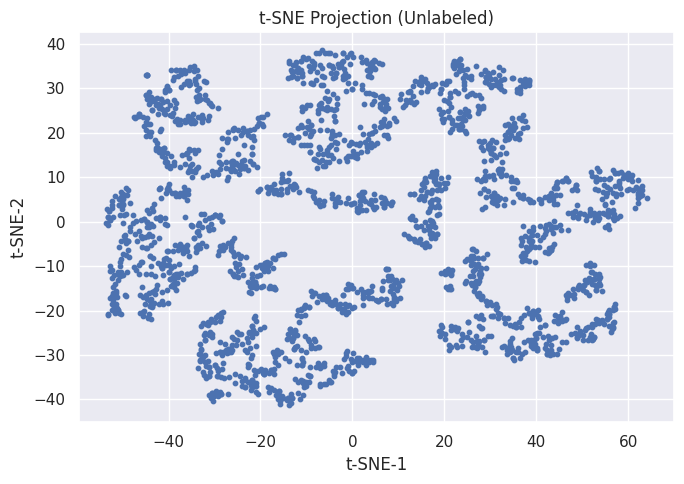

In [ ]:
# t-SNE on scaled clustering features (recommended: run t-SNE on 2D PCA for speed/stability)

# 1) Reduce to 2 PCs for t-SNE input (faster + cleaner)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_cluster_scaled_std)  # <-- StandardScaler output

# 2) t-SNE projection
tsne = TSNE(
    n_components=2,
    perplexity=30,          # good default for ~2240 rows
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca2)

# 3) Plot
plt.figure(figsize=(7,5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.title("t-SNE Projection (Unlabeled)")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

**Observations:**
* The plot shows several dense pockets/islands of customers rather than one uniform blob
* The pockets are not perfectly separated by large empty space everywhere, but the clustering of points into local neighborhoods is clearly visible
* The overall shape suggests a continuum with local groupings, which is common in customer behavior datasets

**Insights:**
* This confirms features contain meaningful structure for segmentation (customers are not randomly distributed)
* The pockets likely reflect combinations of the PCA dimensions is identified:
  * Value + shopping style / promo sensitivity (PC1): income/spend, deal behavior, channel purchases
  * Lifecycle + digital engagement (PC2): tenure + web visits/purchases
* This supports using KMeans to create actionable personas even if groups overlap, because the behavior space is structured but not “hard-separated”
* Important caveat:
  * t-SNE is for visualization only; it can distort global distances, so clustering should still be done on the standardized features (or PCA features)

**Summary:**

The t-SNE visualization shows multiple dense pockets of customers, indicating non-random structure in the standardized behavioral feature space. This supports proceeding with clustering for segmentation, while using t-SNE strictly as a diagnostic visualization (clustering will be performed on standardized features to preserve meaningful distance relationships).

**KMeans silhouette results**

In [ ]:

# X input to clustering: scaled features from Step #10 (StandardScaler)
X = X_cluster_scaled_std

def run_kmeans(X, k, random_state=42):
    km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    return km, labels, sil

for k in [2, 4, 5]:
    _, labels, sil = run_kmeans(X, k)
    print(f"KMeans k={k}: silhouette={sil:.3f}")

KMeans k=2: silhouette=0.295
KMeans k=4: silhouette=0.147
KMeans k=5: silhouette=0.150


**Observations:**
* k=2: silhouette = 0.295 (best of the three)
* k=4: silhouette = 0.147
* k=5: silhouette = 0.150 (slightly better than k=4, but still much lower than k=2)

**Insights:**
* k=2 is the most “naturally separated” split in the data

This typically corresponds to two broad customer groups (often something like higher-value/more active vs lower-value/less active, or deal-driven vs premium, depending on the feature mix).

* The much lower silhouette for k=4 and k=5 tells us that when you force more segments:
  * clusters become more overlapping, which is common in customer behavior data (customers exist on a spectrum)
* Even with lower silhouette, k=4 or k=5 can still be the better business choice if the goal is actionable personas. In marketing, interpretability often matters more than perfect separation

Silhouette analysis shows the strongest natural split at k=2, while k=4–5 provides more actionable segmentation with expected overlap in real customer behavior.

**Summary:**

Silhouette scores indicate the dataset has one dominant broad separation (k=2), while 4–5 clusters produce softer, overlapping personas. For business segmentation, we can select k=4 or k=5 to create interpretable customer personas, while acknowledging that customer behavior is continuous and segments will overlap.


**KMeans (k=4) - Cluster sizes**

In [ ]:
# Choose primary k for reporting
K_CHOSEN = 4

kmeans_model, kmeans_labels, kmeans_sil = run_kmeans(X, K_CHOSEN)
print(f"Chosen KMeans k={K_CHOSEN} silhouette={kmeans_sil:.3f}")

df_kmeans = df_fe.copy()
df_kmeans["Cluster"] = kmeans_labels
df_kmeans["Cluster"] = df_kmeans["Cluster"].astype(int)
df_kmeans["Cluster"].value_counts().sort_index()

Chosen KMeans k=4 silhouette=0.147


,count
Cluster,
0,464
1,498
2,626
3,649


**Observations:**

KMeans k=4 with silhouette 0.147, and the cluster sizes are:
* Cluster 0: 464 customers (~21%)
* Cluster 1: 498 customers (~22%)
* Cluster 2: 626 customers (~28%)
* Cluster 3: 649 customers (~29%)

Total=2237 (which matches clean dataset).

**Insights:**
* This is a healthy segmentation split from a business perspective:
  * No clusters are tiny or “statistically fragile”
  * Even the smallest segment (~21%) is large enough to target with marketing actions
* The clusters are fairly balanced, which often indicates KMeans is partitioning a continuous customer spectrum into four practical personas (consistent with the modest silhouette)
* The silhouette being modest simply means these are “soft segments” with overlap, which is normal in customer behavior data

**Summary:**

With k=4, KMeans produces four well-sized customer segments (each ~21–29% of the population). While silhouette indicates some overlap (expected in real-world behavior data), the segments are large enough to be actionable and suitable for downstream profiling and targeted marketing strategy.

**KMeans (k=4) - Segment Profiles**



In [ ]:
profile_cols = [
    "Income_capped", "Age", "TenureDays", "ChildrenCount", "Recency",
    "TotalSpend", "DealRate", "TotalAccepted",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"
]

cluster_sizes = df_kmeans.groupby("Cluster").size().rename("Count")

cluster_means = df_kmeans.groupby("Cluster")[profile_cols].mean()
cluster_medians = df_kmeans.groupby("Cluster")[profile_cols].median()

print("Cluster sizes:\n", cluster_sizes)
display(cluster_means)
display(cluster_medians)

Cluster sizes:
 Cluster
0    464
1    498
2    626
3    649
Name: Count, dtype: int64


,Income_capped,Age,TenureDays,ChildrenCount,Recency,TotalSpend,DealRate,TotalAccepted,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,,
0,42358.037414,50.053879,313.517241,1.969828,49.512931,154.146552,0.294763,0.178879,2.560345,0.810345,3.678879,6.232759
1,76977.480402,45.132530,336.989960,0.116466,50.877510,1418.441767,0.056579,1.186747,4.748996,6.315261,8.208835,2.508032
2,60466.014441,49.300319,405.736422,0.988818,47.645367,813.785942,0.141268,0.311502,6.621406,3.321086,8.167732,5.367412
3,30666.828968,37.476117,345.369800,0.825886,48.859784,104.329738,0.231573,0.200308,2.226502,0.548536,3.164869,6.776579


,Income_capped,Age,TenureDays,ChildrenCount,Recency,TotalSpend,DealRate,TotalAccepted,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,,
0,42434.0,49.0,307.0,2.0,50.0,81.0,0.300000,0.0,2.0,1.0,3.0,6.0
1,77854.0,44.0,317.5,0.0,54.0,1400.5,0.050000,1.0,4.0,6.0,8.0,2.0
2,60804.0,49.0,429.0,1.0,48.0,763.5,0.125000,0.0,6.0,3.0,8.0,5.0
3,30545.0,37.0,331.0,1.0,49.0,65.0,0.235294,0.0,2.0,0.0,3.0,7.0


**Cluster 0 (n=464, ~21%)**

Key stats(mean/median)
* Income_capped: 42.4k (med ~42.4k)
* TotalSpend: 154 (med ~81) → low value
* DealRate: 0.295 (med ~0.30) → high discount sensitivity
* WebVisitsMonth: 6.23 (med ~6) → high browsing
* WebPurchases: 2.56 (med 2) → low-moderate
* StorePurchases: 3.68 (med 3) → modest
* ChildrenCount: 1.97 (med 2) → family-heavy
* TotalAccepted: 0.18 (med 0) → low responsiveness

Observation

A family-heavy group that browses a lot, spends little, and is deal-driven.

Segment name: “Deal-Seeking Families (High Browsing, Low Spend)”
Business actions
* Family bundles, coupons, entry-level offers
* Cart reminders, simplified checkout
* “Save more” messaging vs premium messaging


---


**Cluster 1 (n=498, ~22%)**

Key stats(mean/median)
* Income_capped: ~77.0k (med ~77.9k) → highest/near-highest
* TotalSpend: ~1418 (med ~1400) → highest value
* DealRate: 0.056 (med 0.05) → lowest discount sensitivity
* StorePurchases: 8.21 (med 8) → high
* CatalogPurchases: 6.32 (med 6) → high
* WebPurchases: 4.75 (med 4) → moderate-high
* WebVisitsMonth: 2.51 (med 2) → low browsing (purposeful buyers)
* TotalAccepted: 1.19 (med 1) → most responsive
* ChildrenCount: 0.12 (med 0) → mostly no kids

Observation

This is the premium segment: high spenders, multi-channel buyers, not deal-driven, and responsive to campaigns.

Segment name: “High-Value Loyalists (Premium Multi-Channel Buyers)”
Business actions
* Loyalty/VIP program, early access, premium recommendations
* Personalized offers (not necessarily discounts)
* Retention focus: protect this segment from churn

---

**Cluster 2 (n=626, ~28%)**

Key stats(mean/median)
* Income_capped: ~60.5k (med ~60.8k) → mid-high
* TotalSpend: ~814 (med ~763.5) → strong value (2nd highest)
* DealRate: 0.141 (med 0.125) → moderate-low
* StorePurchases: 8.17 (med 8) → very high
* WebPurchases: 6.62 (med 6) → highest web purchases
* CatalogPurchases: 3.32 (med 3) → moderate
* WebVisitsMonth: 5.37 (med 5) → moderate-high engagement
* TenureDays: 405.7 (med 429) → longer tenure
* TotalAccepted: 0.31 (med 0) → low-to-moderate responsiveness

Observation

High activity shoppers with strong store + web behavior, solid spend, longer tenure; not especially deal-driven.

Segment name: “Core Active Shoppers (Store + Digital Power Users)”
Business actions
* Cross-sell/upsell, personalization, “next best product”
* Omnichannel experience improvements
* Increase campaign conversion with targeted messaging (not heavy discounts)

---

**Cluster 3 (n=649, ~29%)**

Key stats(mean/median)
* Income_capped: ~30.7k (med ~30.5k) → lowest income
* TotalSpend: ~104 (med ~65) → lowest spend
* DealRate: 0.232 (med ~0.235) → discount sensitive
* WebVisitsMonth: 6.78 (med 7) → highest browsing
* WebPurchases: 2.23 (med 2) → low buying
* StorePurchases: 3.16 (med 3) → low
* CatalogPurchases: 0.55 (med 0) → almost none
* Age: 37.5 (med 37) → youngest group
* TotalAccepted: 0.20 (med 0) → low responsiveness

Observation

Classic “browsers”: younger, low income, low spend, high site visits, low purchasing—conversion opportunity.

Segment name: “Low-Spend Digital Browsers (Low Conversion)”
Business actions
* Onboarding + conversion tactics (email capture, reminders)
* Entry-level offers, first-purchase incentives
* Reduce friction: simplify checkout, highlight value

---

###Cross-segment insights

1. **Clear value tiers exist**
    *  Cluster 1 and 2 are the revenue engine (high spend + high purchase volume)
    * Cluster 0 and 3 are conversion/activation opportunities (high browsing but low spend)
2. **Deal sensitivity cleanly splits segments**
    * Cluster 1 is premium (low deal rate)
    * Clusters 0 and 3 are more price sensitive (higher deal rate)
3. **Campaign responsiveness is concentrated**
    * Cluster 1 has meaningfully higher TotalAccepted (median 1) while others are mostly 0
    * That suggests campaign strategy is currently best aligned with Cluster 1, and other segments may need different messaging/channels

**Summary**

KMeans clustering (k=4) produced four balanced, interpretable customer segments. Two segments represent higher value customers: High-Value Loyalists (high income and spend, multi-channel buyers, low discount sensitivity, most responsive to campaigns) and Core Active Shoppers (strong store and web purchasing, longer tenure, solid spending). The remaining two segments represent lower value but high opportunity populations: Deal-Seeking Families (high browsing, high discount sensitivity, low spend) and Low-Spend Digital Browsers (youngest group, highest web visits, low purchases). These segments support targeted marketing actions such as VIP retention for high-value customers, cross-sell for active shoppers, and conversion-focused strategies for browsers and deal-driven households.
  


**Z-score Cluster Profile Table**

In [ ]:
# Compare clusters on standardized means (easier to see "high vs low")
z_profiles = (cluster_means - cluster_means.mean()) / cluster_means.std()
display(z_profiles)

,Income_capped,Age,TenureDays,ChildrenCount,Recency,TotalSpend,DealRate,TotalAccepted,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,,
0,-0.504185,0.791561,-0.939174,1.302511,0.214593,-0.754135,1.091572,-0.602932,-0.720392,-0.721655,-0.770382,0.532522
1,1.197201,-0.062133,-0.341525,-1.124672,1.227729,1.280848,-1.194757,1.489041,0.345681,1.327728,0.870949,-1.428303
2,0.385739,0.660843,1.408860,0.017770,-1.171985,0.307606,-0.381825,-0.327656,1.257715,0.213049,0.856056,0.076973
3,-1.078755,-1.390272,-0.128162,-0.195608,-0.270337,-0.834319,0.485010,-0.558454,-0.883003,-0.819122,-0.956623,0.818808


#####**How to read the table**
* **Positive** = above average for that feature
* **Negative** = below average
* The bigger the magnitude, the more distinctive the segment

####**Observations & Insights by Cluster**

Cluster 0 — Deal-Seeking Families

Key z-signals:
* ChildrenCount +1.30 (highest) → family-heavy
* DealRate +1.09 → most deal-driven
* WebVisits +0.53 → above-avg browsing
* TotalSpend −0.75, Income −0.50 → below-avg value
* Purchases are below avg: web, catalog, store all negative
* TotalAccepted −0.60 → low marketing responsiveness

Confirms: *family-oriented, discount-sensitive, high browsing but low overall value.*

---
Cluster 1 — High-Value Loyalists (Premium Multi-Channel)

Key z-signals:
* Income +1.20, TotalSpend +1.28 → highest value
* TotalAccepted +1.49 → most responsive to campaigns
* Catalog +1.33, Store +0.87, WebPurchases +0.35 → strong multi-channel buying
* DealRate −1.19 → least discount-sensitive
* WebVisits −1.43 → low browsing, more purposeful purchasing
* Recency +1.23 → this is the only flag: higher recency means less recent purchasing (potentially slipping)

Confirms: *premium segment, responds to campaigns, buys across channels, not deal-driven.*

Note: Recency being high might suggest to position them as "high-value but needs retention attention."

---
Cluster 2 — Core Active Shoppers (Store + Digital Power Users)

Key z-signals:
* TenureDays +1.41 → longest-tenure segment
* WebPurchases +1.26, Store +0.86 → highest buying activity (especially web + store)
* Income +0.39, TotalSpend +0.31 → above-avg value (but not as high as Cluster 1)
* Recency −1.17 → more recently active (good)
* DealRate −0.38 → not particularly deal-driven
* TotalAccepted −0.33 → not very campaign responsive

Confirms: *“engine room” segment — active, loyal (tenure), strong omnichannel purchase behavior.*

---
Cluster 3 — Low-Spend Digital Browsers

Key z-signals:
* Income −1.08, TotalSpend −0.83 → lowest value
* Age −1.39 → youngest segment
* WebVisits +0.82 → highest browsing
* WebPurchases −0.88, Catalog −0.82, Store −0.96 → low purchasing across channels
* DealRate +0.49 → discount sensitive
* TotalAccepted −0.56 → low responsiveness

Confirms: *classic “browse-heavy, low conversion” segment.*

**Summary:**

The standardized (z-score) cluster profiles validate the segmentation story clearly: Cluster 1 is the high-value, multi-channel, campaign-responsive premium segment; Cluster 2 is a long-tenure, highly active shopper segment driven by strong store and web purchasing; Cluster 0 is a family-heavy, discount-sensitive group with low value but higher browsing; and Cluster 3 is a younger, low-value, high-browsing segment with weak conversion. This table demonstrates that the clusters are not arbitrary—they align with interpretable business behaviors across value, channel preference, discount sensitivity, and lifecycle.

**Check CLuster1 Recency being strong**

In [ ]:
df_kmeans.groupby("Cluster")["Recency"].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,464.0,49.512931,28.597449,0.0,25.00,50.0,74.25,99.0
1,498.0,50.877510,28.995439,0.0,26.25,54.0,75.00,99.0
2,626.0,47.645367,29.202720,0.0,23.00,48.0,72.00,99.0
3,649.0,48.859784,28.928292,0.0,24.00,49.0,75.00,99.0


**Observations**
* All clusters have very similar Recency distributions:
  * Means are all around ~48–51 days
  * Medians are all around ~48–54 days
  * IQR (25% to 75%) is very similar across clusters (roughly mid-20s to mid-70s)
  * Max is 99 in all clusters (dataset cap)

Specifically:
* Cluster 0: mean 49.51, median 50
* Cluster 1: mean 50.88, median 54
* Cluster 2: mean 47.65, median 48
* Cluster 3: mean 48.86, median 49

**Insights**
* Recency is not a major differentiator between segments in the final k=4 solution. It’s contributing, but it’s not driving the separation like value (Income/Spend), deal behavior, channel purchasing, and tenure.
* Cluster 1’s recency is only slightly higher (median 54 vs 48–50). This is a minor retention signal, not a major red flag.
* This is actually a good story to tell employers:
  * The clusters are not just “recent vs not recent”
  * They reflect deeper behavioral structure: value, channel mix, discount sensitivity, lifecycle, and campaign responsiveness

**Summary**

Recency distributions are broadly similar across all four clusters (medians ~48–54 days), indicating that recency is not the primary driver of segmentation in this dataset. Instead, segments are more strongly differentiated by customer value (income/spend), channel purchasing behavior, discount sensitivity, tenure, and marketing responsiveness, with only minor differences in recency across groups.

**KMeans (k=4) on PCA(2) — Scatter Plot**

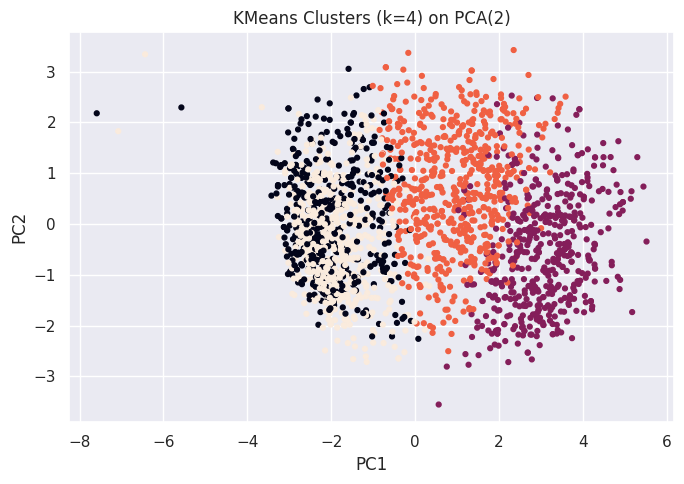

In [ ]:

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=kmeans_labels, s=12)
plt.title(f"KMeans Clusters (k={K_CHOSEN}) on PCA(2)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**Observations**
* The clusters separate primarily along PC1 (left ↔ right).
  * You can see two clusters largely on the left side (negative PC1)
  * Two clusters largely on the right side (positive PC1)
* There is overlap in the middle, which is expected given silhouette (~0.147)
* PC2 provides some additional vertical spread, but PC1 is doing most of the visual separation

**Insights**
* This matches PCA interpretation perfectly:
  * PC1 = Value + shopping style + promo sensitivity (Income/Spend/DealRate + channel activity)
* So this plot tells a clean story:
  * segments are primarily structured by customer value and purchasing behavior, not random splits.
* The overlap supports earlier silhouette result:
  * These are soft personas, not perfectly separable “hard clusters,” which is normal for customer behavior data

**Summary**
The PCA(2) visualization shows KMeans clusters separating mainly along PC1, which aligns with PCA loadings indicating PC1 represents customer value and shopping behavior (income/spend, channel purchasing, and deal sensitivity). Some overlap is present near the center, consistent with the modest silhouette score and the continuous nature of customer behavior. Overall, the plot supports that the clusters are behaviorally meaningful and not arbitrary.

**DBSCAN k-distance plot (eps selection)**

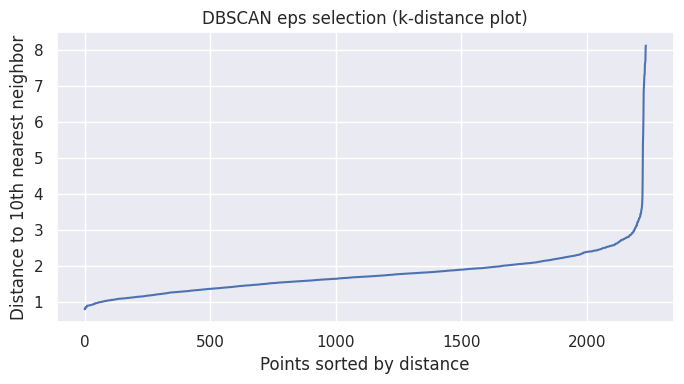

In [ ]:
min_samples = 10

nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = nn.kneighbors(X)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7,4))
plt.plot(k_dist)
plt.title("DBSCAN eps selection (k-distance plot)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

**Observations**
* The curve increases slowly for most points, then rises sharply near the far right.
* That sharp rise is the classic DBSCAN “elbow” pattern.
* Visually, the elbow occurs just before the steep spike, roughly around a distance of ~3.0 to ~3.5 (based on the y-axis).

**Insights**
* This plot suggests that most customers live in a dense core, while a small fraction of points at the end are much farther from their neighbors (likely outliers/noise).
* Choosing eps near the elbow (≈3.0–3.5) is a good balance:
  * Smaller eps → too strict → too much noise / tiny clusters
  * Larger eps → too loose → everything merges into one cluster
* Business interpretation:
  * DBSCAN here is likely to behave more as an outlier detector (dense core + a few unusual customers), rather than finding multiple distinct customer personas.

**Summary**

The DBSCAN k-distance plot shows a clear elbow around eps ≈ 3.0–3.5, indicating a dense customer core with a small set of outliers at higher neighbor distances. This supports selecting eps near the elbow to identify core density structure and potential outliers, while using KMeans for actionable multi-segment personas.

**DBSCAN eps sweep**

In [ ]:
min_samples = 10  # matches k-distance plot
for eps in [3.0, 3.5, 4.0]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise} ({n_noise/len(labels):.1%})")

eps=3.0: clusters=1, noise=18 (0.8%)
eps=3.5: clusters=1, noise=12 (0.5%)
eps=4.0: clusters=1, noise=12 (0.5%)


**Observations**
* Across all tested eps values (3.0, 3.5, 4.0), DBSCAN finds:
  * clusters = 1 (one core cluster)
  * very low noise:
    * eps=3.0 → 18 noise (0.8%)
    * eps=3.5 → 12 noise (0.5%)
    * eps=4.0 → 12 noise (0.5%)

**Insights**
* This is a clear signal that the customer data does not form multiple distinct density-separated groups.
* Instead, it forms:
  * one large dense core population (almost everyone), and
  * a very small set of outliers (0.5–0.8%)
* That reinforces the narrative already have from KMeans + PCA:
  * Customer behavior is more of a continuum than separate “islands.”
  * DBSCAN is best used here for outlier detection, not persona segmentation.
* The fact that noise decreases slightly from eps=3.0 to 3.5/4.0 means:
  * a slightly larger neighborhood radius captures a few borderline points into the core cluster
  * eps=3.5 is a good balanced choice (matches elbow)

**Summary**

The DBSCAN eps sweep shows stable behavior across a reasonable eps range: DBSCAN consistently identifies a single dense core cluster containing nearly all customers, with only 0.5–0.8% of points labeled as noise. This indicates the dataset lacks multiple density-separated customer groups; DBSCAN is therefore most useful for detecting unusual/outlier customers, while KMeans provides the actionable multi-segment personas for marketing strategy.


**DBSCAN final cluster counts**

In [ ]:
EPS = 3.5
db = DBSCAN(eps=EPS, min_samples=min_samples)
db_labels = db.fit_predict(X)

df_dbscan = df_fe.copy()
df_dbscan["Cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN eps={EPS}, min_samples={min_samples}")
print("Number of clusters:", n_clusters)
print("Noise points (-1):", n_noise, f"({n_noise/len(db_labels):.1%})")
print(df_dbscan["Cluster"].value_counts())

DBSCAN eps=3.5, min_samples=10
Number of clusters: 1
Noise points (-1): 12 (0.5%)
Cluster
 0    2225
-1      12
Name: count, dtype: int64


**Observations**
* DBSCAN identified:
  * 1 core cluster with 2225 customers
  * 12 noise points labeled -1 (0.5% of the dataset)
* Total customers = 2225 + 12 = 2237, which matches the cleaned dataset size

**Insights**
* This confirms DBSCAN’s role in this project is not multi-persona segmentation, but outlier detection:
  * The customer base is largely one dense behavioral population.
  * Only a very small number of customers behave “unusually” relative to their neighbors
* Those 12 noise points are worth a short “what are they?” check:
  * They could be very high-income/very high-spend, extreme deal-rate users, unusual channel-only shoppers, etc.
  * Even if you don’t fully deep dive, it’s a good “real-world” insight: there are always edge-case customers.

**Summary**

DBSCAN (eps=3.5, min_samples=10) produced one dominant core cluster containing 99.5% of customers and flagged 0.5% as noise/outliers. This indicates customer behavior does not form multiple density-separated groups; instead, segmentation is better achieved through KMeans for actionable personas, while DBSCAN is useful for identifying a small set of atypical customer behaviors for separate review.

**DBSCAN core vs noise comparison**

In [ ]:
profile_cols = [
    "Income_capped","Age","TenureDays","ChildrenCount","Recency",
    "TotalSpend","DealRate","TotalAccepted",
    "NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumWebVisitsMonth"
]

core_df = df_dbscan[df_dbscan["Cluster"] != -1].copy()
noise_df = df_dbscan[df_dbscan["Cluster"] == -1].copy()

print("Core size:", core_df.shape[0])
print("Noise size:", noise_df.shape[0])

print("\n--- Core summary (means) ---")
display(core_df[profile_cols].mean().to_frame("CoreMean"))

if noise_df.shape[0] > 0:
    print("\n--- Noise summary (means) ---")
    display(noise_df[profile_cols].mean().to_frame("NoiseMean"))

Core size: 2225
Noise size: 12

--- Core summary (means) ---


,CoreMean
Income_capped,51811.609627
Age,45.109663
TenureDays,354.088989
ChildrenCount,0.951461
Recency,49.136629
TotalSpend,605.092135
DealRate,0.179388
TotalAccepted,0.448539
NumWebPurchases,4.062921
NumCatalogPurchases,2.628315



--- Noise summary (means) ---


,NoiseMean
Income_capped,38548.351667
Age,43.000000
TenureDays,298.416667
ChildrenCount,0.833333
Recency,43.166667
TotalSpend,726.500000
DealRate,0.377721
TotalAccepted,0.083333
NumWebPurchases,8.583333
NumCatalogPurchases,9.000000


**Observations**

Core (n=2225) — “typical customer”
* Income_capped: ~51.8k
* TotalSpend: ~605
* DealRate: ~0.179
* TotalAccepted: ~0.449
* WebPurchases: ~4.06
* CatalogPurchases: ~2.63
* StorePurchases: ~5.82
* WebVisitsMonth: ~5.31
* TenureDays: ~354

Noise / outliers (n=12) — “atypical customer pattern”
* Income_capped: ~38.5k (lower than core)
* TotalSpend: ~726.5 (higher than core)
* DealRate: ~0.378 (much higher — very deal-driven)
* TotalAccepted: ~0.083 (very low responsiveness)
* WebPurchases: ~8.58 (much higher)
* CatalogPurchases: ~9.00 (much higher)
* StorePurchases: ~0.17 (near-zero store buying)
* WebVisitsMonth: ~6.92 (higher browsing)
* TenureDays: ~298 (slightly lower than core)

**Isights (What these outliers represent)**
1. These are not random outliers — they are a coherent niche behavior group

They look like:
* “Digital + Catalog heavy buyers”
* Very discount-driven (high DealRate)
* Almost zero store purchases (strong channel avoidance)
* High purchase intensity onnline/catalog but low campaign acceptance

2. Business interpretation

This is a small segment of customers who:
* buy heavily through web/catalog channels
* appear price sensitive
* and do not respond to campaigns (or campaigns may not match their preferences)

This is exactly the kind of insight you can call out as:
* Channel strategy opportunity (optimize web/catalog experience)
* Campaign mismatch possibility (they buy, but don’t accept offers—maybe the offers aren’t relevant, or they purchase without needing them)
* Margin management (deal-driven behavior)

3. Why DBSCAN found only 12

Because their behavior is far from “average” in a density sense: they sit on the fringe of the main distribution, even though they’re not necessarily “bad data.”

**Summary**

DBSCAN identified one dominant customer core (99.5% of customers) and flagged 12 outliers (0.5%). These outliers represent a distinct behavioral niche: customers with lower income but higher spending, unusually high web and catalog purchases, near-zero store purchases, and much higher discount sensitivity. Despite being active buyers, they show very low campaign acceptance, suggesting either a campaign-channel mismatch or a group that purchases without promotions. This supports using KMeans for broad, actionable personas while using DBSCAN to detect niche behavioral patterns and edge-case segments.


**“Noise differs from overall” output**

In [ ]:
if noise_df.shape[0] > 0:
    overall_means = df_dbscan[profile_cols].mean()
    diff = (noise_df[profile_cols].mean() - overall_means).sort_values(ascending=False)
    print("Top features where NOISE is higher than overall:\n", diff.head(8))
    print("\nTop features where NOISE is lower than overall:\n", diff.tail(8))

Top features where NOISE is higher than overall:
 TotalSpend             120.756594
NumCatalogPurchases      6.337506
NumWebPurchases          4.496163
NumWebVisitsMonth        1.597489
DealRate                 0.197269
ChildrenCount           -0.117494
TotalAccepted           -0.363247
Age                     -2.098346
dtype: float64

Top features where NOISE is lower than overall:
 DealRate                 0.197269
ChildrenCount           -0.117494
TotalAccepted           -0.363247
Age                     -2.098346
NumStorePurchases       -5.627701
Recency                 -5.937938
TenureDays             -55.373678
Income_capped       -13192.109505
dtype: float64


**Observations**

NOISE is higher than overall (largest positive differences)
* TotalSpend +120.76 → outliers spend more than average
* NumCatalogPurchases +6.34 → much more catalog buying
* NumWebPurchases +4.50 → much more web buying
* NumWebVisitsMonth +1.60 → more browsing
* DealRate +0.197 → significantly more deal-driven

NOISE is lower than overall (largest negative differences)
* NumStorePurchases −5.63 → almost no store buying (biggest behavioral difference)
* Income_capped −13,192 → lower income than the average customer
* TenureDays −55.37 → slightly newer customers vs average
* Recency −5.94 → slightly more recently active (not huge, but notable)
* TotalAccepted −0.36 → much lower campaign acceptance
* Age −2.10 → slightly younger

*(The “DealRate” showing up in both lists is just because you printed the top/bottom slices; ignore that duplication—directionally it’s clearly higher in NOISE.)*

**Insights**

“Digital/Catalog Heavy, Store-Avoiding Deal Shoppers”

These DBSCAN outliers form a coherent niche:
* They buy heavily online and via catalog, barely in-store.
* They are more discount-sensitive.
* They spend more than average despite having lower income.
* They accept campaigns less, which could indicate campaign mismatch (channel/content) rather than lack of engagement.

Actionable recommendations
* Channel strategy: prioritize web/catalog experience and merchandising for this niche.
* Offer design: test different promo types (bundles, free shipping, loyalty credits) vs generic campaigns.
* Measurement: check whether their low “TotalAccepted” is because they buy without clicking “accept” (attribution mismatch) or because the offers truly don’t resonate.

**Summary**

The DBSCAN outliers are characterized by higher spending, dramatically higher web and catalog purchases, and near-zero store purchases, combined with higher discount sensitivity and lower campaign acceptance. This indicates a niche group of digitally oriented, deal-driven customers whose behavior differs meaningfully from the overall population and may benefit from specialized web/catalog-focused engagement strategies.

**DBSCAN (eps=3.5) on PCA(2) — Visual validation**

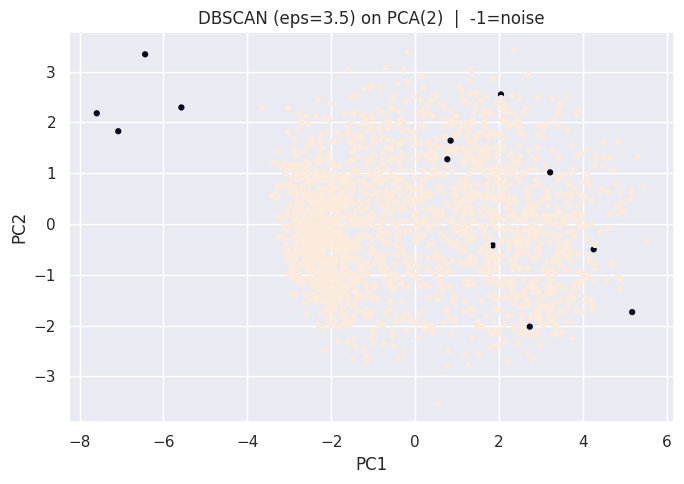

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=db_labels, s=12)
plt.title(f"DBSCAN (eps={EPS}) on PCA(2)  |  -1=noise")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()

**Observations**
* Almost all points belong to the single core cluster (light-colored cloud)
* The noise points (-1) appear as a small set of black dots scattered around the edges of the main distribution.
* Noise points are located on the fringes/extremes of PC space:
  * far left / far right on PC1
  * and some at more extreme PC2 values

**Insights**
* This plot visually confirms what eps sweep and counts showed:
  * the data forms one dense customer population
  * with a small number of atypical customers (0.5%) that lie outside the densest region
* It reinforces the correct interpretation:
  * DBSCAN is acting as an outlier detector, not a multi-persona clustering method for this dataset
* Since we already characterized these outliers as “digital/catalog heavy, store-avoiding deal shoppers,” this plot supports that they occupy unusual combinations of value/purchase behavior (PC1) and lifecycle/digital engagement (PC2)

**Summary**

The DBSCAN PCA visualization shows one dominant dense customer core and a small set of noise points located on the fringes of the distribution. This confirms that customer behavior is largely continuous rather than forming multiple density-separated groups. As a result, DBSCAN is best used here for identifying niche/outlier behaviors, while KMeans provides the primary, actionable customer personas.

###**Conclusion**

This project built a customer segmentation solution to help the business better target marketing actions and improve ROI. After cleaning the dataset (income missing values, unrealistic ages, and rare marital-status categories), I engineered a set of behavioral features capturing customer value (Income_capped, TotalSpend), engagement (TotalPurchases, Recency), channel preference (web/catalog/store purchases, web visits), discount sensitivity (DealRate), lifecycle (TenureDays), and marketing responsiveness (TotalAccepted).

Exploratory analysis showed strong relationships among value and purchase variables (e.g., income and spend), while discount sensitivity and browsing behavior followed different patterns—confirming that segmentation should not be based on a single variable like income. PCA supported this by showing the dominant customer differences are driven by value/shopping style (PC1) and lifecycle/digital engagement (PC2). A t-SNE projection also revealed non-random “pockets” of customers, suggesting meaningful structure for clustering.

Two techniques was applied for clustering:
* **KMeans** was used to create actionable personas (best for business segmentation)
* **DBSCAN** was used to test for density-separated groups and identify outliers (best as an outlier detector in this dataset)

###**Key Findings**
1. **KMeans created 4 actionable customer segments (k=4)**

      Silhouette analysis showed the strongest natural split at k=2, but k=4 produced more usable personas for marketing strategy, with balanced segment sizes (~21–29% each). The segments are:
    * **Deal-Seeking Families (High Browsing, Low Spend)**
      * Higher ChildrenCount, higher DealRate, higher web visits, low total spend
      * Strategy: family bundles, coupons, value messaging, cart reminders
    * **High-Value Loyalists (Premium Multi-Channel Buyers)**
      * Highest Income_capped and TotalSpend, strong store/catalog, lowest DealRate, highest TotalAccepted
      * Strategy: VIP/loyalty perks, premium recommendations, retention focus, personalized offers (not discount-heavy)
    * **Core Active Shoppers (Store + Digital Power Users)**
      * High store and web purchases, solid spend, longer tenure, moderate deal sensitivity
      * Strategy: cross-sell/upsell, omnichannel personalization, product recommendation and reorder nudges
    * **Low-Spend Digital Browsers (Low Conversion)**
      * Lowest income/spend, highest web visits, low purchasing across channels, higher deal sensitivity
      * Strategy: onboarding, first-purchase incentives, reduce checkout friction, retargeting campaigns

2. **DBSCAN validated the data structure and identified a niche outlier group**

      DBSCAN (eps≈3.5) consistently produced one dense core cluster (99.5% of customers) and a small set of outliers (~0.5%). This indicates customer behavior is largely continuous and does not form multiple density-separated groups. The outliers represent a niche behavioral pattern:

    * higher TotalSpend than average, much higher web/catalog purchases
    * near-zero store purchases
    * higher DealRate and low TotalAccepted

      This suggests DBSCAN is best used here for detecting niche behaviors/outliers, while KMeans provides the main segmentation solution.

###**Recommendations**

**Recommended model for deployment: KMeans (k=4)**

Why this is the best solution
* Produces interpretable, business-actionable personas aligned with value, channel behavior, and promo sensitivity
* Segment sizes are large enough to operationalize
* Easy to deploy and refresh (re-run monthly/quarterly)
* Supports targeted marketing, personalization, and channel optimization

How to operationalize the segments
1. Assign each customer a segment label (Cluster 0–3) using the saved scaler + KMeans model
2. Build campaign playbooks per segment (message, channel, offer type)
3. Track KPIs by segment:
    * conversion rate, repeat rate, average order value, retention, and campaign lift
4. Use DBSCAN as an outlier monitor (flag unusual web/catalog-heavy, store-avoiding deal shoppers)

###**Expected business impact**

If the company targets the two largest opportunity groups with tailored strategies:
* Low-Spend Digital Browsers (conversion focus): even a small lift in conversion can create meaningful revenue due to large segment size
* Deal-Seeking Families (value messaging + bundles): can increase basket size while controlling discount cost

A realistic initial target could be:
* 2–5% improvement in conversion for browser-heavy customers
* +3–6% improvement in average spend for deal-seeking families through bundling and personalized offers
* Reduced churn risk for high-value customers with VIP retention programs

###**Risk & Limitations**
* KMeans segments overlap (silhouette is modest), which is expected in real-world behavior data; segments are “soft personas,” not perfectly separated groups.
* Results may shift over time as customer behavior changes; segmentation should be refreshed periodically.
* WebConversionRate can produce extreme values due to low visit counts—monitor and consider capping if needed.

###**Next Steps**
* Validate cluster stability over time (monthly refresh + drift checks)
* Test alternate clustering (e.g., GMM or HDBSCAN) if required by business needs
* Add segment-level uplift experiments (A/B testing per segment)
* Incorporate additional features if available (e.g., product categories, customer service interactions, geography)